# Coastal Erosion Threshold Detection & Forecasting

## Publication-Quality Research Notebook

**Objective:** Identify scientifically defensible **per-factor** erosion thresholds from DSAS transect data and oceanographic forcing (wave, wind, current), then forecast erosion risk 24 months ahead using SARIMA + Monte Carlo uncertainty propagation.

### Pipeline Overview
1. **Monthly Dataset Conversion** — Convert Wave, Wind, Current NetCDFs to uniform monthly format
2. **DSAS Transect → Year-wise Labels** — 5-class annual classification (eroded_high, eroded_low, stable, accreted_low, accreted_high)
3. **Erosion Event Year Labeling** — Identify which years had erosion events
4. **Combine Erosion Years with Forcing Data** — Merge annual forcing features with erosion labels
5. **Mann-Whitney / Cliff's δ** — Identify statistically significant forcing features
6. **4-Method Ensemble Thresholds** — ROC/Youden, Bayesian Logistic, Change-Point, Mutual Information (per-factor, no combinations)
7. **Per-Factor Threshold Rules** — Independent threshold for each factor: *"If wave > X, erosion begins"*
8. **SARIMA Forecasting** — AIC grid search per variable
9. **Monte Carlo Simulation** — 2 000 realisations for erosion probability
10. **Retreat Predictions** — Physical shoreline movement in meters

## Section 0 — Setup and Data Loading

Install and import all required libraries, then load the four datasets:
1. **DSAS Shoreline CSV** — Transect-based statistics from QGIS
2. **Wave NetCDF** — Global Ocean Waves Reanalysis (VHM0, VTPK, VMDR, VSDX, VSDY)
3. **Wind NetCDF** — Monthly Sea Surface Wind (wind_speed, eastward_wind, northward_wind)
4. **Current NetCDF** — Physics Reanalysis (uo, vo at surface, zos)


In [1]:
# =============================================================================
# Section 0.1 — Import all required libraries
# =============================================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scientific / statistical
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (LeaveOneOut, StratifiedKFold,
                                     cross_val_predict)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             mutual_info_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# Time-series
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

# Plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Output directories
import os
os.makedirs('./figures', exist_ok=True)
os.makedirs('./outputs', exist_ok=True)

print("✓ Libraries loaded successfully")


✓ Libraries loaded successfully


In [2]:
# =============================================================================
# Section 0.2 — Load all datasets
# =============================================================================

DATA_PATH = "notebook_data"
SHORELINE_FILE = f"{DATA_PATH}/all_stats_new.csv"
WAVE_FILE = f"{DATA_PATH}/Global_Ocean_Waves_Reanalysis_2009_2024.nc"
WIND_FILE = f"{DATA_PATH}/Global Ocean Monthly Mean Sea Surface Wind and Stress from Scatterometer and Model_2009_2024.nc"
CURRENT_FILE = f"{DATA_PATH}/Global Ocean Physics Reanalysis(current_data)_2009_2024.nc"

# ── Load shoreline statistics ──
dsas_raw = pd.read_csv(SHORELINE_FILE)
print("=" * 60)
print("SHORELINE DATA SUMMARY (Transect-Based)")
print("=" * 60)
print(f"Shape: {dsas_raw.shape}")
print(f"Columns: {list(dsas_raw.columns)}")
print(f"Year range: {dsas_raw['SCE_closest_year'].min()} – {dsas_raw['SCE_closest_year'].max()}")
display(dsas_raw.head(10))

# ── Load NetCDF datasets ──
wave_ds = xr.open_dataset(WAVE_FILE)
wind_ds = xr.open_dataset(WIND_FILE)
current_ds = xr.open_dataset(CURRENT_FILE)

for name, ds in [('Wave', wave_ds), ('Wind', wind_ds), ('Current', current_ds)]:
    print(f"\n{name}: {list(ds.data_vars)} | time {ds.sizes.get('time', '?')} steps")


SHORELINE DATA SUMMARY (Transect-Based)
Shape: (187, 20)
Columns: ['id', 'SCE', 'SCE_highest_unc', 'SCE_trend', 'SCE_closest_year', 'SCE_farthest_year', 'NSM', 'NSM_highest_unc', 'NSM_trend', 'EPR', 'EPR_unc', 'EPR_trend', 'LRR', 'LR2', 'LSE', 'LCI', 'WLR', 'WR2', 'WSE', 'WCI']
Year range: 2010 – 2024


,id,SCE,SCE_highest_unc,SCE_trend,SCE_closest_year,SCE_farthest_year,NSM,NSM_highest_unc,NSM_trend,EPR,EPR_unc,EPR_trend,LRR,LR2,LSE,LCI,WLR,WR2,WSE,WCI
0,1,36.16,1,accreting,2023,2022,-1.33,1,eroding,-0.09,0.1,eroding,0.51,0.08,7.10,1.09,0.51,0.08,7.10,1.09
1,2,25.38,1,accreting,2023,2022,3.22,1,accreting,0.22,0.1,accreting,-0.03,0.00,6.19,0.95,-0.03,0.00,6.19,0.95
2,3,24.11,1,accreting,2024,2018,14.45,1,accreting,1.00,0.1,accreting,-0.38,0.06,6.12,0.94,-0.38,0.06,6.12,0.94
3,4,43.20,1,accreting,2021,2011,-0.11,1,eroding,-0.01,0.1,eroding,-0.51,0.06,8.19,1.25,-0.51,0.06,8.19,1.25
4,5,36.91,1,accreting,2021,2011,-5.48,1,eroding,-0.38,0.1,eroding,-0.38,0.04,8.18,1.25,-0.38,0.04,8.18,1.25
5,6,39.38,1,accreting,2021,2011,-5.57,1,eroding,-0.38,0.1,eroding,-0.52,0.06,8.69,1.33,-0.52,0.06,8.69,1.33
6,7,39.03,1,accreting,2019,2011,-1.91,1,eroding,-0.13,0.1,eroding,-0.40,0.03,9.00,1.38,-0.40,0.03,9.00,1.38
7,8,40.18,1,accreting,2019,2011,-2.77,1,eroding,-0.19,0.1,eroding,-0.23,0.01,9.77,1.49,-0.23,0.01,9.77,1.49
8,9,45.26,1,accreting,2019,2022,-0.59,1,eroding,-0.04,0.1,eroding,-0.34,0.02,10.11,1.55,-0.34,0.02,10.11,1.55
9,10,51.55,1,accreting,2019,2022,-12.07,1,eroding,-0.83,0.1,eroding,-0.13,0.00,11.74,1.79,-0.13,0.00,11.74,1.79



Wave: ['VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW1', 'VMDR_SW2', 'VMDR_WW', 'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK'] | time 42601 steps

Wind: ['eastward_stress', 'eastward_stress_bias', 'eastward_stress_sdd', 'eastward_wind', 'eastward_wind_bias', 'eastward_wind_sdd', 'northward_stress', 'northward_stress_bias', 'northward_stress_sdd', 'northward_wind', 'northward_wind_bias', 'northward_wind_sdd', 'number_of_observations', 'wind_speed', 'wind_speed_bias', 'wind_speed_sdd', 'wind_stress_magnitude', 'wind_stress_magnitude_bias', 'wind_stress_magnitude_sdd'] | time 175 steps

Current: ['bottomT', 'mlotst', 'siconc', 'sithick', 'so', 'thetao', 'uo', 'usi', 'vo', 'vsi', 'zos'] | time 175 steps


## Section 1 — DSAS Transect Classification (5-Class Annual Labels)

This section converts transect-wise DSAS long-term statistics into **year-wise coastal change labels** using Net Shoreline Movement (NSM) with uncertainty-aware thresholds.

| Class | NSM Condition | Interpretation |
|-------|-------------|----------------|
| Eroded High | NSM < −5 m | Severe retreat |
| Eroded Low | −5 ≤ NSM < −1 m | Marginal retreat |
| Stable | −1 ≤ NSM ≤ +1 m | Within measurement noise |
| Accreted Low | +1 < NSM ≤ +5 m | Marginal advance |
| Accreted High | NSM > +5 m | Significant advance |


In [3]:
# =============================================================================
# Section 1.1 — Convert transect-wise data to year-wise with 5-class labels
# =============================================================================

HIGH_EROSION_THRESHOLD = -5.0
LOW_EROSION_THRESHOLD  = -1.0
LOW_ACCRETION_THRESHOLD = 1.0
HIGH_ACCRETION_THRESHOLD = 5.0
EPR_UNCERTAINTY = 0.47  # m/yr uniform DSAS uncertainty

def classify_nsm(nsm):
    if nsm < HIGH_EROSION_THRESHOLD:
        return 'eroded_high'
    elif nsm < LOW_EROSION_THRESHOLD:
        return 'eroded_low'
    elif nsm <= LOW_ACCRETION_THRESHOLD:
        return 'stable'
    elif nsm <= HIGH_ACCRETION_THRESHOLD:
        return 'accreted_low'
    else:
        return 'accreted_high'

# --- Per-transect classification ---
dsas_df = dsas_raw.copy()
dsas_df['epr_class'] = dsas_df['NSM'].apply(classify_nsm)
dsas_df['erosion_flag'] = (dsas_df['NSM'] < LOW_EROSION_THRESHOLD).astype(int)

# --- Aggregate transects to YEARLY statistics (one row per year) ---
dsas_df['measurement_year'] = dsas_df['SCE_closest_year']
shoreline_annual = dsas_df.groupby('measurement_year').agg(
    annual_NSM=('NSM', 'mean'),
    NSM_median=('NSM', 'median'),
    NSM_std=('NSM', 'std'),
    NSM_min=('NSM', 'min'),
    NSM_max=('NSM', 'max'),
    NSM_count=('NSM', 'count'),
    EPR_mean=('EPR', 'mean'),
    EPR_std=('EPR', 'std'),
    LRR_mean=('LRR', 'mean'),
    SCE_max=('SCE', 'max'),
).reset_index().rename(columns={'measurement_year': 'year'})

shoreline_annual['Change_Class'] = shoreline_annual['annual_NSM'].apply(classify_nsm)
shoreline_annual['Erosion_Binary'] = (shoreline_annual['annual_NSM'] < LOW_EROSION_THRESHOLD).astype(int)

# Beach-scale summary
transect_stats = {
    'Total_Transects': len(dsas_df),
    'Mean_NSM': dsas_df['NSM'].mean(),
    'Median_NSM': dsas_df['NSM'].median(),
    'Std_NSM': dsas_df['NSM'].std(),
    'Pct_Eroding': (dsas_df['erosion_flag'].sum() / len(dsas_df)) * 100,
    'Max_Erosion': dsas_df['NSM'].min(),
    'Max_Accretion': dsas_df['NSM'].max(),
    'Mean_EPR': dsas_df['EPR'].mean(),
}

print("=" * 60)
print("YEAR-WISE SHORELINE CHANGE TABLE")
print("=" * 60)
print("(Each year = one record, classified by average NSM across transects)")
print()

# Display the yearwise table clearly
yearwise_display = shoreline_annual[['year', 'annual_NSM', 'Change_Class', 'Erosion_Binary',
                                      'NSM_count', 'EPR_mean']].copy()
yearwise_display.columns = ['Year', 'Avg_NSM (m)', 'Classification', 'Is_Erosion',
                             'Num_Transects', 'Avg_EPR (m/yr)']
print(yearwise_display.to_string(index=False))

print(f"\n{'─'*60}")
print("CLASS DISTRIBUTION:")
print(shoreline_annual['Change_Class'].value_counts().to_string())
print(f"\nErosion years (NSM < {LOW_EROSION_THRESHOLD}): "
      f"{shoreline_annual['Erosion_Binary'].sum()} / {len(shoreline_annual)}")
print(f"Mean NSM across transects: {transect_stats['Mean_NSM']:.2f} m")
print(f"Eroding transects: {transect_stats['Pct_Eroding']:.1f}%")

YEAR-WISE SHORELINE CHANGE TABLE
(Each year = one record, classified by average NSM across transects)

 Year  Avg_NSM (m) Classification  Is_Erosion  Num_Transects  Avg_EPR (m/yr)
 2010   -11.260000    eroded_high           1              1       -0.780000
 2011   -28.241000    eroded_high           1             20       -1.946500
 2012    -6.750000    eroded_high           1              5       -0.466000
 2014     0.870000         stable           0              1        0.060000
 2016    -0.522000         stable           0              5       -0.034000
 2017     5.150000  accreted_high           0              2        0.355000
 2018   -13.135000    eroded_high           1              2       -0.905000
 2019    -5.165000    eroded_high           1             10       -0.356000
 2020    -7.979333    eroded_high           1             15       -0.549333
 2021   -15.008667    eroded_high           1             30       -1.034000
 2022   -18.553333    eroded_high           1     

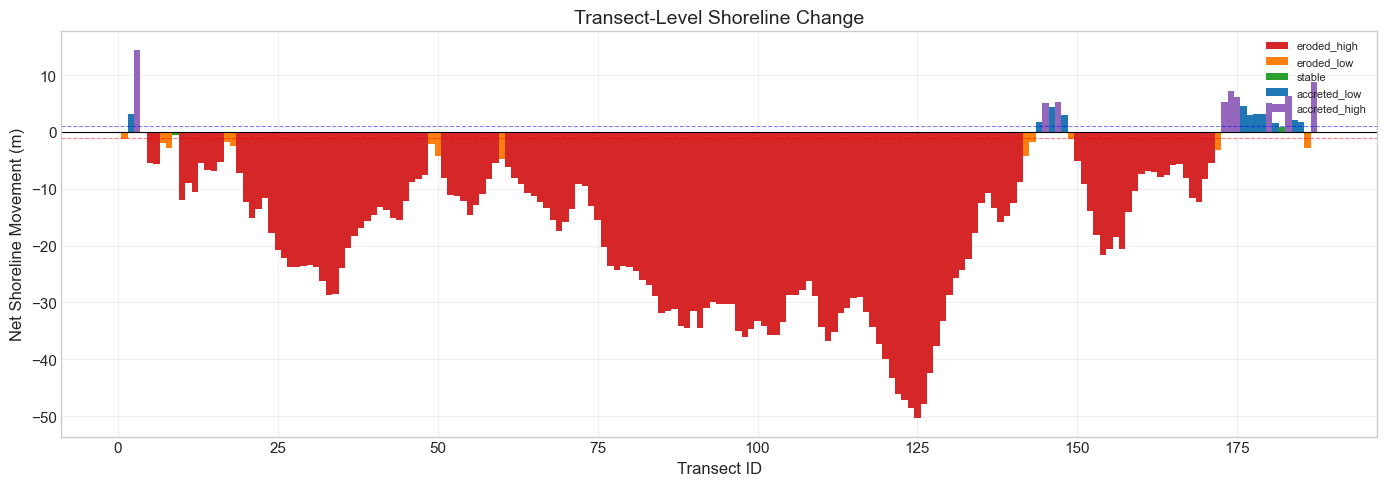

In [4]:
# =============================================================================
# Section 1.2 — Spatial profile plot (transect-level)
# =============================================================================

color_map = {
    'eroded_high': '#d62728', 'eroded_low': '#ff7f0e',
    'stable': '#2ca02c', 'accreted_low': '#1f77b4', 'accreted_high': '#9467bd'
}

fig, ax = plt.subplots(figsize=(14, 5))
for cls, clr in color_map.items():
    mask = dsas_df['epr_class'] == cls
    ax.bar(dsas_df.loc[mask, 'id'], dsas_df.loc[mask, 'NSM'],
           color=clr, label=cls, width=1.0, edgecolor='none')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(LOW_EROSION_THRESHOLD, color='red', ls='--', lw=0.8, alpha=0.5)
ax.axhline(LOW_ACCRETION_THRESHOLD, color='blue', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Transect ID')
ax.set_ylabel('Net Shoreline Movement (m)')
ax.set_title('Transect-Level Shoreline Change')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./figures/transect_profile.png', dpi=150)
plt.show()


In [5]:
# =============================================================================
# Section 1.3 — Extract erosion event years from peak retreat positions
# =============================================================================

eroded_transects = dsas_df[dsas_df['erosion_flag'] == 1]
year_col = 'SCE_closest_year'
erosion_year_counts = eroded_transects[year_col].value_counts().sort_index()

# Severity: if year appears in eroded_high set
high_erosion_transects = dsas_df[dsas_df['epr_class'] == 'eroded_high']
severe_years = set(high_erosion_transects[year_col].unique())

all_erosion_years = set(shoreline_annual.loc[shoreline_annual['Erosion_Binary'] == 1, 'year'].values)

print("=" * 60)
print("EROSION EVENT YEARS")
print("=" * 60)
for yr in sorted(all_erosion_years):
    sev = "HIGH" if yr in severe_years else "LOW"
    cnt = erosion_year_counts.get(yr, 0)
    print(f"  {yr}: {cnt} eroding transects ({sev} severity)")

print(f"\nTotal erosion years: {len(all_erosion_years)}")
print(f"Non-erosion years: {len(shoreline_annual) - len(all_erosion_years)}")


EROSION EVENT YEARS
  2010: 1 eroding transects (HIGH severity)
  2011: 19 eroding transects (HIGH severity)
  2012: 4 eroding transects (HIGH severity)
  2018: 1 eroding transects (HIGH severity)
  2019: 9 eroding transects (HIGH severity)
  2020: 13 eroding transects (HIGH severity)
  2021: 29 eroding transects (HIGH severity)
  2022: 5 eroding transects (HIGH severity)
  2023: 80 eroding transects (HIGH severity)

Total erosion years: 9
Non-erosion years: 4


## Section 2 — Convert Wave, Wind & Current Datasets to Monthly Format

All three oceanographic forcing datasets (Wave, Wind, Current) are first converted to a **uniform monthly time series** format. This ensures consistency across all variables before further analysis.

**Steps:**
1. Extract relevant variables from each NetCDF dataset
2. Resample/aggregate to **monthly** frequency
3. Save each as a clean monthly CSV
4. Then aggregate monthly → annual for erosion threshold analysis

| Driver Category | Variables | Monthly Aggregation |
|----------------|-----------|---------------------|
| **Wave** | VHM0 (Sig. wave height) | Max, Mean, Std |
| | VTPK (Peak wave period) | Max, Mean |
| | VMDR (Wave direction) | Mean |
| | VSDX, VSDY (Stokes drift) | Magnitude mean/max |
| **Wind** | wind_speed | Max, Mean, Std |
| | eastward_wind, northward_wind | Mean |
| **Current** | uo, vo (Surface currents) | Magnitude max/mean |
| | zos (Sea surface height) | Max, Mean |

In [6]:
# =============================================================================
# Section 2.1 — Convert Wind NetCDF to Monthly Dataset
# =============================================================================

WIND_VARS = ['wind_speed', 'eastward_wind', 'northward_wind']
STORM_WIND_THRESHOLD = 10.0  # m/s

wind_df = wind_ds[WIND_VARS].to_dataframe().reset_index()
wind_df = wind_df.dropna(subset=['wind_speed'])

def assign_monsoon_year(time):
    """April (Year N) – March (Year N+1) → Monsoon Year N"""
    ts = pd.Timestamp(time)
    return ts.year if ts.month >= 4 else ts.year - 1

wind_df['monsoon_year'] = wind_df['time'].apply(assign_monsoon_year)
wind_df['year_month'] = wind_df['time'].dt.to_period('M')
wind_df['is_storm_wind'] = (wind_df['wind_speed'] > STORM_WIND_THRESHOLD).astype(int)

# ── Monthly Wind Dataset ──
wind_monthly = wind_df.groupby(['monsoon_year', 'year_month']).agg({
    'wind_speed': ['max', 'mean', 'std'],
    'eastward_wind': 'mean',
    'northward_wind': 'mean',
    'is_storm_wind': 'sum',
    'time': 'first',
}).reset_index()
wind_monthly.columns = ['monsoon_year', 'year_month',
                        'WindSpeed_max', 'WindSpeed_mean', 'WindSpeed_std',
                        'EastWind_mean', 'NorthWind_mean',
                        'StormDays_wind', 'time']

print("=" * 60)
print("MONTHLY WIND DATASET")
print("=" * 60)
print(f"Shape: {wind_monthly.shape}")
print(f"Period: {wind_monthly['year_month'].min()} – {wind_monthly['year_month'].max()}")
print(f"Columns: {[c for c in wind_monthly.columns if c not in ['time']]}")
display(wind_monthly.head(12))

# ── Annual aggregation for threshold analysis ──
wind_annual = wind_df.groupby('monsoon_year').agg({
    'wind_speed': ['max', lambda x: np.percentile(x, 90), 'mean', 'std'],
    'eastward_wind': 'mean',
    'northward_wind': 'mean',
    'is_storm_wind': 'sum',
}).reset_index()
wind_annual.columns = ['monsoon_year',
                       'wind_max_annual', 'wind_p90', 'wind_mean_annual', 'wind_std_annual',
                       'eastwind_mean_annual', 'northwind_mean_annual',
                       'storm_days_wind_total']

print(f"\nWind monthly: {wind_monthly.shape}  |  Wind annual: {wind_annual.shape}")

MONTHLY WIND DATASET
Shape: (175, 9)
Period: 2009-08 – 2024-02
Columns: ['monsoon_year', 'year_month', 'WindSpeed_max', 'WindSpeed_mean', 'WindSpeed_std', 'EastWind_mean', 'NorthWind_mean', 'StormDays_wind']


,monsoon_year,year_month,WindSpeed_max,WindSpeed_mean,WindSpeed_std,EastWind_mean,NorthWind_mean,StormDays_wind,time
0,2009,2009-08,5.74,5.74,NaN,5.29,0.54,0,2009-08-01
1,2009,2009-09,5.73,5.73,NaN,5.60,0.37,0,2009-09-01
2,2009,2009-10,3.37,3.37,NaN,2.47,0.00,0,2009-10-01
3,2009,2009-11,2.77,2.77,NaN,0.20,0.72,0,2009-11-01
4,2009,2009-12,2.47,2.47,NaN,-0.21,-0.72,0,2009-12-01
5,2009,2010-01,2.22,2.22,NaN,0.37,0.04,0,2010-01-01
6,2009,2010-02,2.22,2.22,NaN,-0.17,0.38,0,2010-02-01
7,2009,2010-03,2.38,2.38,NaN,0.42,0.42,0,2010-03-01
8,2010,2010-04,2.71,2.71,NaN,1.30,0.44,0,2010-04-01
9,2010,2010-05,4.50,4.50,NaN,4.12,0.85,0,2010-05-01



Wind monthly: (175, 9)  |  Wind annual: (15, 8)


In [7]:
# =============================================================================
# Section 2.2 — Convert Wave NetCDF to Monthly Dataset (3-hourly → monthly)
# =============================================================================

WAVE_VARS = ['VHM0', 'VTPK', 'VMDR', 'VSDX', 'VSDY']
STORM_WAVE_THRESHOLD = 2.0  # meters

# Select single nearest longitude point (wave file may have multiple)
wave_sel = wave_ds
if 'longitude' in wave_ds.dims and wave_ds.sizes['longitude'] > 1:
    wave_sel = wave_ds.isel(longitude=0)
    print(f"Selected wave longitude: {float(wave_sel.longitude.values)}")

wave_df = wave_sel[WAVE_VARS].to_dataframe().reset_index()
wave_df = wave_df.dropna(subset=['VHM0'])
wave_df['monsoon_year'] = wave_df['time'].apply(assign_monsoon_year)
wave_df['year_month'] = wave_df['time'].dt.to_period('M')

wave_df['wave_energy'] = wave_df['VHM0']**2 * wave_df['VTPK']
wave_df['stokes_drift_mag'] = np.sqrt(wave_df['VSDX']**2 + wave_df['VSDY']**2)
wave_df['is_storm_wave'] = (wave_df['VHM0'] > STORM_WAVE_THRESHOLD).astype(int)

print(f"Wave records: {len(wave_df)} (3-hourly)")
print(f"Time range: {wave_df['time'].min()} – {wave_df['time'].max()}")

# ── Monthly Wave Dataset (aggregate 3-hourly → monthly) ──
wave_monthly = wave_df.groupby(['monsoon_year', 'year_month']).agg({
    'VHM0': ['max', 'mean', 'std'],
    'VTPK': ['max', 'mean'],
    'VMDR': 'mean',
    'stokes_drift_mag': ['max', 'mean'],
    'wave_energy': 'sum',
    'is_storm_wave': 'sum',
    'time': 'first',
}).reset_index()
wave_monthly.columns = ['monsoon_year', 'year_month',
                        'VHM0_max', 'VHM0_mean', 'VHM0_std',
                        'VTPK_max', 'VTPK_mean',
                        'VMDR_mean',
                        'StokesDrift_max', 'StokesDrift_mean',
                        'CumWaveEnergy', 'StormDays_wave', 'time']

# StormDays: convert from 3-hourly storm counts to approximate days
wave_monthly['StormDays_wave'] = (wave_monthly['StormDays_wave'] / 8.0).round(1)

print("=" * 60)
print("MONTHLY WAVE DATASET")
print("=" * 60)
print(f"Shape: {wave_monthly.shape}")
print(f"Period: {wave_monthly['year_month'].min()} – {wave_monthly['year_month'].max()}")
print(f"Columns: {[c for c in wave_monthly.columns if c not in ['time']]}")
display(wave_monthly.head(12))

# ── Annual aggregation for threshold analysis ──
wave_annual = wave_df.groupby('monsoon_year').agg({
    'VHM0':  ['max', lambda x: np.percentile(x, 90), 'mean', 'std'],
    'VTPK':  ['max', 'mean'],
    'VMDR':  'mean',
    'stokes_drift_mag': ['max', 'mean'],
    'wave_energy': 'sum',
    'is_storm_wave': 'sum',
}).reset_index()
wave_annual.columns = ['monsoon_year',
                       'Hm0_max_annual', 'Hm0_p90', 'Hm0_mean_annual', 'Hm0_std_annual',
                       'Tp_max_annual', 'Tp_mean_annual',
                       'VMDR_mean_annual',
                       'stokesdrift_max_annual', 'stokesdrift_mean_annual',
                       'cumwave_energy_annual', 'storm_days_wave_total']

# Convert storm counts to days (3-hourly → days)
wave_annual['storm_days_wave_total'] = (wave_annual['storm_days_wave_total'] / 8.0).round(1)

print(f"\nWave monthly: {wave_monthly.shape}  |  Wave annual: {wave_annual.shape}")

Selected wave longitude: 79.79998779296875
Wave records: 42601 (3-hourly)
Time range: 2009-08-01 21:00:00 – 2024-02-29 21:00:00
MONTHLY WAVE DATASET
Shape: (175, 13)
Period: 2009-08 – 2024-02
Columns: ['monsoon_year', 'year_month', 'VHM0_max', 'VHM0_mean', 'VHM0_std', 'VTPK_max', 'VTPK_mean', 'VMDR_mean', 'StokesDrift_max', 'StokesDrift_mean', 'CumWaveEnergy', 'StormDays_wave']


,monsoon_year,year_month,VHM0_max,VHM0_mean,VHM0_std,VTPK_max,VTPK_mean,VMDR_mean,StokesDrift_max,StokesDrift_mean,CumWaveEnergy,StormDays_wave,time
0,2009,2009-08,2.66,2.153361,0.245166,18.070000,12.907843,212.241241,0.143178,0.095343,14648.277344,22.8,2009-08-01 21:00:00
1,2009,2009-09,3.05,2.066542,0.343492,20.100000,12.748209,210.411911,0.152315,0.095104,13313.975586,16.4,2009-09-01 00:00:00
2,2009,2009-10,2.99,1.594597,0.419160,19.170000,12.855283,187.024841,0.170880,0.035913,8317.942383,3.8,2009-10-01 00:00:00
3,2009,2009-11,2.20,1.258333,0.326925,17.059999,11.808750,189.738297,0.117047,0.028094,4524.312012,1.0,2009-11-01 00:00:00
4,2009,2009-12,1.81,1.147984,0.244613,17.480000,10.599839,199.178635,0.120416,0.027292,3586.570557,0.0,2009-12-01 00:00:00
5,2009,2010-01,1.53,1.127460,0.149597,17.420000,12.571856,198.270111,0.098489,0.023338,4090.303223,0.0,2010-01-01 00:00:00
6,2009,2010-02,1.55,1.036384,0.172782,20.870001,13.007365,202.815628,0.063246,0.017212,3133.653320,0.0,2010-02-01 00:00:00
7,2009,2010-03,1.50,1.163427,0.163623,21.660000,13.861976,179.948456,0.076158,0.014708,4832.979492,0.0,2010-03-01 00:00:00
8,2010,2010-04,2.06,1.383292,0.272335,18.879999,12.955708,181.481995,0.078102,0.027729,6317.816406,0.4,2010-04-01 00:00:00
9,2010,2010-05,2.53,1.820847,0.377049,19.400000,12.238912,202.733093,0.142127,0.073770,10149.020508,10.9,2010-05-01 00:00:00



Wave monthly: (175, 13)  |  Wave annual: (15, 12)


In [8]:
# =============================================================================
# Section 2.3 — Convert Current NetCDF to Monthly Dataset (surface level)
# =============================================================================

CURRENT_VARS = ['uo', 'vo', 'zos']

# Select surface depth (index 0) for uo, vo
if 'depth' in current_ds.dims:
    current_surface = current_ds.isel(depth=0)
else:
    current_surface = current_ds

current_df = current_surface[CURRENT_VARS].to_dataframe().reset_index()
current_df = current_df.dropna(subset=['uo'])
current_df['monsoon_year'] = current_df['time'].apply(assign_monsoon_year)
current_df['year_month'] = current_df['time'].dt.to_period('M')
current_df['current_mag'] = np.sqrt(current_df['uo']**2 + current_df['vo']**2)

# ── Monthly Current Dataset ──
current_monthly = current_df.groupby(['monsoon_year', 'year_month']).agg({
    'current_mag': ['max', 'mean'],
    'uo': 'mean',
    'vo': 'mean',
    'zos': ['max', 'mean'],
    'time': 'first',
}).reset_index()
current_monthly.columns = ['monsoon_year', 'year_month',
                           'CurrentMag_max', 'CurrentMag_mean',
                           'UO_mean', 'VO_mean',
                           'ZOS_max', 'ZOS_mean', 'time']

print("=" * 60)
print("MONTHLY CURRENT DATASET")
print("=" * 60)
print(f"Shape: {current_monthly.shape}")
print(f"Period: {current_monthly['year_month'].min()} – {current_monthly['year_month'].max()}")
print(f"Columns: {[c for c in current_monthly.columns if c not in ['time']]}")
display(current_monthly.head(12))

# ── Annual aggregation for threshold analysis ──
current_annual = current_df.groupby('monsoon_year').apply(
    lambda g: pd.Series({
        'ucurr_max_annual':  g['current_mag'].max(),
        'ucurr_p90':         np.percentile(g['current_mag'].dropna(), 90),
        'ucurr_mean_annual': g['current_mag'].mean(),
        'ucurr_std_annual':  g['current_mag'].std(),
        'uo_mean_annual':    g['uo'].mean(),
        'vo_mean_annual':    g['vo'].mean(),
        'zos_max_annual':    g['zos'].max(),
        'zos_mean_annual':   g['zos'].mean(),
        'cum_current_annual': g['current_mag'].sum(),
    })
).reset_index()

print(f"\nCurrent monthly: {current_monthly.shape}  |  Current annual: {current_annual.shape}")

MONTHLY CURRENT DATASET
Shape: (175, 9)
Period: 2009-08 – 2024-02
Columns: ['monsoon_year', 'year_month', 'CurrentMag_max', 'CurrentMag_mean', 'UO_mean', 'VO_mean', 'ZOS_max', 'ZOS_mean']


,monsoon_year,year_month,CurrentMag_max,CurrentMag_mean,UO_mean,VO_mean,ZOS_max,ZOS_mean,time
0,2009,2009-08,0.319277,0.319277,0.264901,-0.178228,0.312815,0.312815,2009-08-01
1,2009,2009-09,0.417729,0.417729,0.342418,-0.239265,0.357982,0.357982,2009-09-01
2,2009,2009-10,0.089683,0.089683,-0.082400,0.035401,0.386059,0.386059,2009-10-01
3,2009,2009-11,0.302491,0.302491,-0.272835,0.130619,0.463576,0.463576,2009-11-01
4,2009,2009-12,0.238861,0.238861,-0.236824,0.031129,0.523087,0.523087,2009-12-01
5,2009,2010-01,0.208159,0.208159,-0.208136,-0.003052,0.515152,0.515152,2010-01-01
6,2009,2010-02,0.196752,0.196752,-0.184942,0.067141,0.513016,0.513016,2010-02-01
7,2009,2010-03,0.158907,0.158907,-0.147710,0.058596,0.482803,0.482803,2010-03-01
8,2010,2010-04,0.022682,0.022682,-0.020753,0.009156,0.432142,0.432142,2010-04-01
9,2010,2010-05,0.203210,0.203210,0.151982,-0.134892,0.467544,0.467544,2010-05-01



Current monthly: (175, 9)  |  Current annual: (15, 10)


### Section 2.4 — Unified Monthly Datasets (Saved as CSV)

All three forcing datasets (Wave, Wind, Current) have been converted to the **same monthly format**. Each row = one month, with consistent `monsoon_year` and `year_month` columns. Below we merge them into a single monthly dataset and save individual + combined CSVs.

In [9]:
# =============================================================================
# Section 2.4 — Display monthly datasets
# =============================================================================

# Merge into one combined monthly dataset
monthly_combined = wave_monthly.merge(
    wind_monthly, on=['monsoon_year', 'year_month'], how='outer', suffixes=('_wave', '_wind')
)
monthly_combined = monthly_combined.merge(
    current_monthly, on=['monsoon_year', 'year_month'], how='outer'
)
monthly_combined = monthly_combined.sort_values('year_month').reset_index(drop=True)

print("=" * 60)
print("MONTHLY DATASET SUMMARY")
print("=" * 60)
print(f"  Wave monthly  : {wave_monthly.shape[0]} months × {wave_monthly.shape[1] - 2} features")
print(f"  Wind monthly  : {wind_monthly.shape[0]} months × {wind_monthly.shape[1] - 2} features")
print(f"  Current monthly: {current_monthly.shape[0]} months × {current_monthly.shape[1] - 2} features")
print(f"  Combined monthly: {monthly_combined.shape}")

print(f"\n{'='*60}")
print("COMBINED MONTHLY FORCING (first 12 months)")
print("=" * 60)
display(monthly_combined.head(12))

MONTHLY DATASET SUMMARY
  Wave monthly  : 175 months × 11 features
  Wind monthly  : 175 months × 7 features
  Current monthly: 175 months × 7 features
  Combined monthly: (175, 27)

COMBINED MONTHLY FORCING (first 12 months)


,monsoon_year,year_month,VHM0_max,VHM0_mean,VHM0_std,VTPK_max,VTPK_mean,VMDR_mean,StokesDrift_max,StokesDrift_mean,...,NorthWind_mean,StormDays_wind,time_wind,CurrentMag_max,CurrentMag_mean,UO_mean,VO_mean,ZOS_max,ZOS_mean,time
0,2009,2009-08,2.66,2.153361,0.245166,18.070000,12.907843,212.241241,0.143178,0.095343,...,0.54,0,2009-08-01,0.319277,0.319277,0.264901,-0.178228,0.312815,0.312815,2009-08-01
1,2009,2009-09,3.05,2.066542,0.343492,20.100000,12.748209,210.411911,0.152315,0.095104,...,0.37,0,2009-09-01,0.417729,0.417729,0.342418,-0.239265,0.357982,0.357982,2009-09-01
2,2009,2009-10,2.99,1.594597,0.419160,19.170000,12.855283,187.024841,0.170880,0.035913,...,0.00,0,2009-10-01,0.089683,0.089683,-0.082400,0.035401,0.386059,0.386059,2009-10-01
3,2009,2009-11,2.20,1.258333,0.326925,17.059999,11.808750,189.738297,0.117047,0.028094,...,0.72,0,2009-11-01,0.302491,0.302491,-0.272835,0.130619,0.463576,0.463576,2009-11-01
4,2009,2009-12,1.81,1.147984,0.244613,17.480000,10.599839,199.178635,0.120416,0.027292,...,-0.72,0,2009-12-01,0.238861,0.238861,-0.236824,0.031129,0.523087,0.523087,2009-12-01
5,2009,2010-01,1.53,1.127460,0.149597,17.420000,12.571856,198.270111,0.098489,0.023338,...,0.04,0,2010-01-01,0.208159,0.208159,-0.208136,-0.003052,0.515152,0.515152,2010-01-01
6,2009,2010-02,1.55,1.036384,0.172782,20.870001,13.007365,202.815628,0.063246,0.017212,...,0.38,0,2010-02-01,0.196752,0.196752,-0.184942,0.067141,0.513016,0.513016,2010-02-01
7,2009,2010-03,1.50,1.163427,0.163623,21.660000,13.861976,179.948456,0.076158,0.014708,...,0.42,0,2010-03-01,0.158907,0.158907,-0.147710,0.058596,0.482803,0.482803,2010-03-01
8,2010,2010-04,2.06,1.383292,0.272335,18.879999,12.955708,181.481995,0.078102,0.027729,...,0.44,0,2010-04-01,0.022682,0.022682,-0.020753,0.009156,0.432142,0.432142,2010-04-01
9,2010,2010-05,2.53,1.820847,0.377049,19.400000,12.238912,202.733093,0.142127,0.073770,...,0.85,0,2010-05-01,0.203210,0.203210,0.151982,-0.134892,0.467544,0.467544,2010-05-01


In [10]:
# =============================================================================
# Section 2.5 — Merge monthly → annual for threshold analysis
# =============================================================================

env_annual = wave_annual.merge(wind_annual, on='monsoon_year', how='outer')
env_annual = env_annual.merge(current_annual, on='monsoon_year', how='outer')

# Restrict to period with reliable data
env_annual = env_annual[(env_annual['monsoon_year'] >= 2009) &
                        (env_annual['monsoon_year'] <= 2024)]
env_annual = env_annual.sort_values('monsoon_year').reset_index(drop=True)
env_annual = env_annual.ffill().bfill()

# Drop columns that are still entirely NaN (e.g., wave data unavailable at location)
nan_cols = env_annual.columns[env_annual.isna().all()]
if len(nan_cols) > 0:
    print(f"⚠ Dropping {len(nan_cols)} all-NaN columns: {list(nan_cols)}")
    env_annual = env_annual.drop(columns=nan_cols)

print("=" * 60)
print("MERGED ANNUAL FORCING MATRIX")
print("=" * 60)
print(f"Shape: {env_annual.shape}")
print(f"Years: {env_annual['monsoon_year'].min()} – {env_annual['monsoon_year'].max()}")
print(f"\nFeatures ({len(env_annual.columns)}):")
for col in env_annual.columns:
    print(f"  • {col}")

display(env_annual.head())

MERGED ANNUAL FORCING MATRIX
Shape: (15, 28)
Years: 2009 – 2023

Features (28):
  • monsoon_year
  • Hm0_max_annual
  • Hm0_p90
  • Hm0_mean_annual
  • Hm0_std_annual
  • Tp_max_annual
  • Tp_mean_annual
  • VMDR_mean_annual
  • stokesdrift_max_annual
  • stokesdrift_mean_annual
  • cumwave_energy_annual
  • storm_days_wave_total
  • wind_max_annual
  • wind_p90
  • wind_mean_annual
  • wind_std_annual
  • eastwind_mean_annual
  • northwind_mean_annual
  • storm_days_wind_total
  • ucurr_max_annual
  • ucurr_p90
  • ucurr_mean_annual
  • ucurr_std_annual
  • uo_mean_annual
  • vo_mean_annual
  • zos_max_annual
  • zos_mean_annual
  • cum_current_annual


,monsoon_year,Hm0_max_annual,Hm0_p90,Hm0_mean_annual,Hm0_std_annual,Tp_max_annual,Tp_mean_annual,VMDR_mean_annual,stokesdrift_max_annual,stokesdrift_mean_annual,...,storm_days_wind_total,ucurr_max_annual,ucurr_p90,ucurr_mean_annual,ucurr_std_annual,uo_mean_annual,vo_mean_annual,zos_max_annual,zos_mean_annual,cum_current_annual
0,2009,3.05,2.200,1.444182,0.496186,21.660000,12.540305,197.312119,0.170880,0.042081,...,0,0.417729,0.348812,0.241482,0.102690,-0.065691,-0.012207,0.523087,0.444311,1.931858
1,2010,3.35,2.391,1.666308,0.543905,21.360001,11.792288,214.215302,0.180278,0.063346,...,0,0.337974,0.257771,0.160405,0.087209,-0.000814,-0.061291,0.578631,0.467391,1.924863
2,2011,3.50,2.280,1.585133,0.517983,22.879999,13.037524,200.798004,0.177200,0.049644,...,0,0.383896,0.307926,0.213665,0.095790,0.006104,-0.048219,0.549944,0.448648,2.563978
3,2012,3.54,2.280,1.589620,0.475368,20.809999,12.819727,198.269119,0.191050,0.051018,...,0,0.524217,0.298409,0.203220,0.127275,-0.005392,-0.032400,0.555742,0.472503,2.438637
4,2013,3.72,2.420,1.700616,0.537138,21.120001,12.949185,201.299866,0.224722,0.056456,...,0,0.419063,0.387674,0.254862,0.119697,0.046032,-0.081535,0.541704,0.451038,3.058341


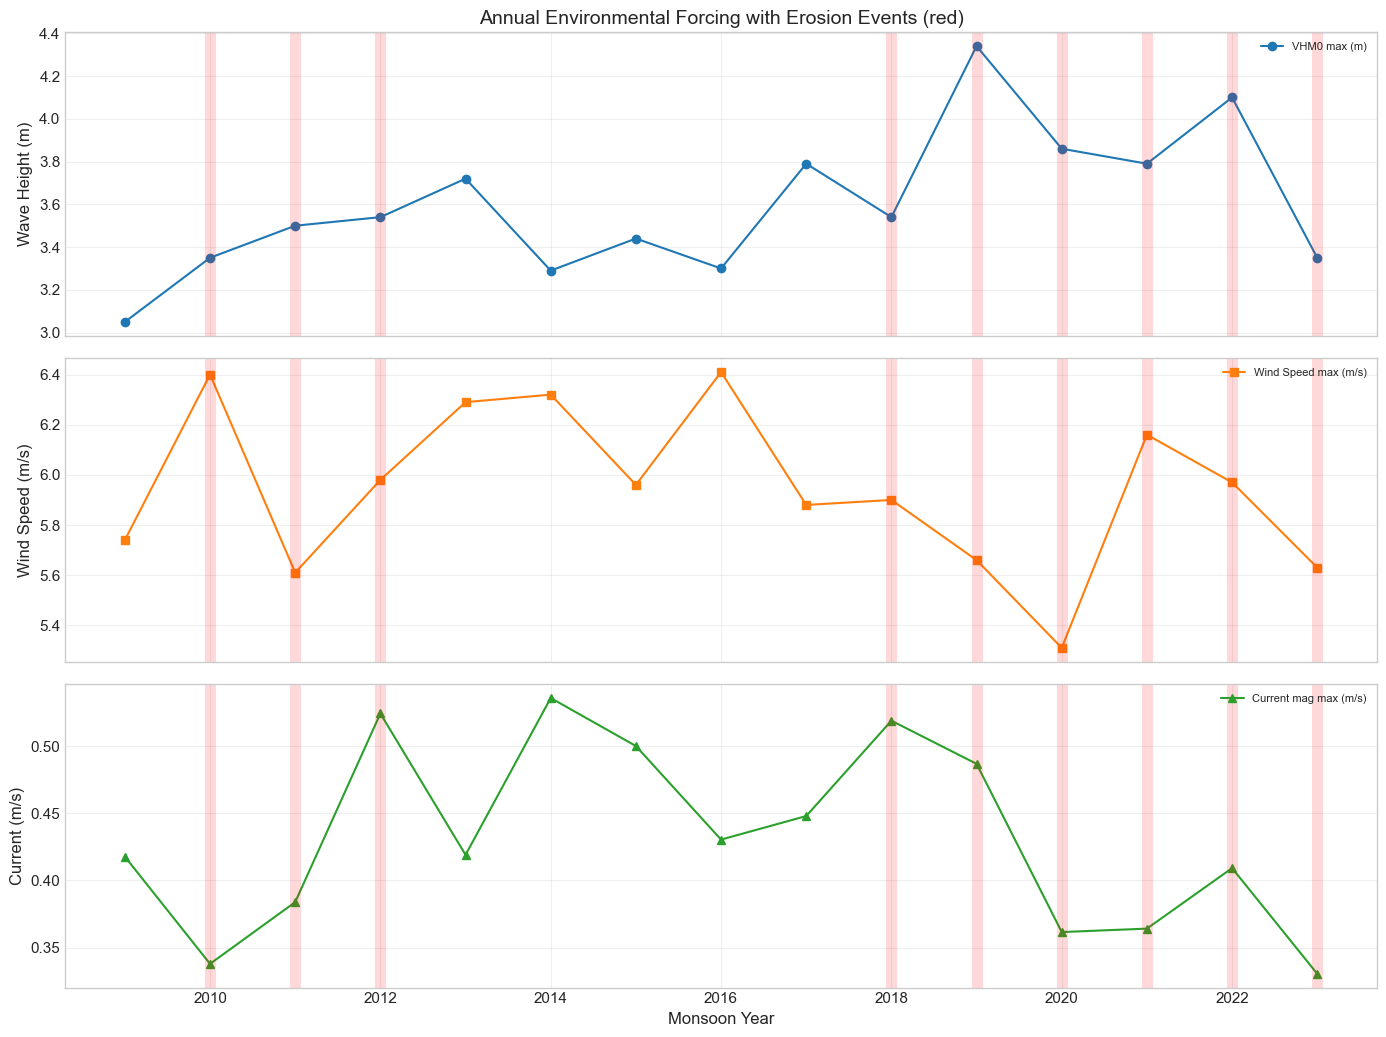

In [11]:
# =============================================================================
# Section 2.5 — Time series plot with erosion event overlay
# =============================================================================

# Dynamically choose which variables to plot based on what's available
plot_configs = [
    ('Hm0_max_annual', 'Wave Height (m)', 'VHM0 max (m)', 'o-', '#1f77b4'),
    ('wind_max_annual', 'Wind Speed (m/s)', 'Wind Speed max (m/s)', 's-', '#ff7f0e'),
    ('ucurr_max_annual', 'Current (m/s)', 'Current mag max (m/s)', '^-', '#2ca02c'),
]

available_plots = [(col, yl, lb, mk, cl) for col, yl, lb, mk, cl in plot_configs
                   if col in env_annual.columns]

n_plots = max(len(available_plots), 1)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3.5 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

for i, (col, ylabel, label, marker, color) in enumerate(available_plots):
    ax = axes[i]
    ax.plot(env_annual['monsoon_year'], env_annual[col], marker, color=color, label=label)
    for yr in all_erosion_years:
        ax.axvline(yr, color='red', alpha=0.15, lw=8)
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_title('Annual Environmental Forcing with Erosion Events (red)')

if available_plots:
    axes[-1].set_xlabel('Monsoon Year')
else:
    axes[0].text(0.5, 0.5, 'No environmental forcing data available for plotting',
                 ha='center', va='center', transform=axes[0].transAxes)

plt.tight_layout()
plt.savefig('./figures/env_timeseries.png', dpi=150)
plt.show()

## Section 3 — Erosion Event Labeling and Dataset Join

This section creates the **binary-labeled combined dataset** by merging annual forcing features with actual shoreline erosion observations.

Then performs **Mann-Whitney U tests** with **Cliff's delta** effect sizes to identify which environmental drivers show statistically significant differences between erosion and non-erosion years.


In [12]:
# =============================================================================
# Section 3.1 — Restrict to overlapping years and create analysis dataset
# =============================================================================

# Merge annual forcing with shoreline labels
analysis_df = env_annual.merge(
    shoreline_annual[['year', 'annual_NSM', 'Erosion_Binary', 'Change_Class', 'NSM_count']],
    left_on='monsoon_year', right_on='year', how='inner'
).drop(columns=['year'], errors='ignore')

analysis_df = analysis_df.rename(columns={'Erosion_Binary': 'erosion_label'})

# Severity label (for diagnosis)
analysis_df['severity'] = analysis_df['Change_Class'].map(
    {'eroded_high': 2, 'eroded_low': 1, 'stable': 0,
     'accreted_low': 0, 'accreted_high': 0}
).fillna(0).astype(int)

print("=" * 60)
print("ANALYSIS DATASET")
print("=" * 60)
print(f"Shape: {analysis_df.shape}")
print(f"Years: {analysis_df['monsoon_year'].min()} – {analysis_df['monsoon_year'].max()}")
print(f"Erosion years: {analysis_df['erosion_label'].sum()} / {len(analysis_df)}")
print(f"Base rate: {analysis_df['erosion_label'].mean():.2%}")

display(analysis_df[['monsoon_year', 'annual_NSM', 'erosion_label', 'Change_Class']].to_string(index=False))


ANALYSIS DATASET
Shape: (12, 33)
Years: 2010 – 2023
Erosion years: 9 / 12
Base rate: 75.00%


' monsoon_year  annual_NSM  erosion_label  Change_Class\n         2010  -11.260000              1   eroded_high\n         2011  -28.241000              1   eroded_high\n         2012   -6.750000              1   eroded_high\n         2014    0.870000              0        stable\n         2016   -0.522000              0        stable\n         2017    5.150000              0 accreted_high\n         2018  -13.135000              1   eroded_high\n         2019   -5.165000              1   eroded_high\n         2020   -7.979333              1   eroded_high\n         2021  -15.008667              1   eroded_high\n         2022  -18.553333              1   eroded_high\n         2023  -20.000465              1   eroded_high'

In [13]:
# =============================================================================
# Section 3.2 — Mann-Whitney U test + Cliff's delta effect size
# =============================================================================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

def cliffs_delta(x, y):
    """
    Compute Cliff's delta (non-parametric effect size).
    δ = (#{x_i > y_j} - #{x_i < y_j}) / (n_x × n_y)
    |δ| < 0.147: negligible, < 0.33: small, < 0.474: medium, else: large
    """
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan, 'N/A'
    more = sum(1 for xi in x for yj in y if xi > yj)
    less = sum(1 for xi in x for yj in y if xi < yj)
    delta = (more - less) / (nx * ny)
    abs_d = abs(delta)
    if abs_d < 0.147:
        magnitude = 'negligible'
    elif abs_d < 0.33:
        magnitude = 'small'
    elif abs_d < 0.474:
        magnitude = 'medium'
    else:
        magnitude = 'large'
    return round(delta, 4), magnitude


# ── Step 1: Normalize erosion_label to integer 0/1 ───────────────────────────
analysis_df['erosion_label'] = analysis_df['erosion_label'].astype(int)

print("=== erosion_label value counts ===")
print(analysis_df['erosion_label'].value_counts())
print()

# ── Step 2: Build feature list ────────────────────────────────────────────────
exclude_cols = ['monsoon_year', 'erosion_label', 'severity',
                'annual_NSM', 'Change_Class', 'NSM_count']

feature_cols = [c for c in analysis_df.columns if c not in exclude_cols]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}\n")

# ── Step 3: Split groups ──────────────────────────────────────────────────────
erosion_rows     = analysis_df[analysis_df['erosion_label'] == 1]
non_erosion_rows = analysis_df[analysis_df['erosion_label'] == 0]

print(f"Erosion rows    : {len(erosion_rows)}")
print(f"Non-erosion rows: {len(non_erosion_rows)}\n")

# ── Step 4: Per-feature non-NaN counts (diagnostic) ──────────────────────────
print("=== Per-feature sample sizes ===")
for feat in feature_cols:
    e  = erosion_rows[feat].dropna()
    ne = non_erosion_rows[feat].dropna()
    print(f"  {feat:40s}  erosion={len(e):4d}  non_erosion={len(ne):4d}")
print()

# ── Step 5: Run Mann-Whitney U + Cliff's delta ────────────────────────────────
mw_results = []

for feat in feature_cols:
    e_vals  = erosion_rows[feat].dropna()
    ne_vals = non_erosion_rows[feat].dropna()

    # Need at least 1 sample in each group (lowered from 2)
    if len(e_vals) < 1 or len(ne_vals) < 1:
        print(f"  [SKIPPED] '{feat}' — insufficient samples "
              f"(erosion={len(e_vals)}, non_erosion={len(ne_vals)})")
        continue

    try:
        stat, pval = mannwhitneyu(e_vals, ne_vals, alternative='two-sided')
    except Exception:
        # If Mann-Whitney fails (e.g., identical values), use fallback
        stat, pval = np.nan, 1.0

    cd, cd_mag = cliffs_delta(e_vals.values, ne_vals.values)

    mw_results.append({
        'feature':           feat,
        'erosion_mean':      round(float(e_vals.mean()),  4),
        'non_erosion_mean':  round(float(ne_vals.mean()), 4),
        'difference':        round(float(e_vals.mean() - ne_vals.mean()), 4),
        'U_statistic':       round(float(stat), 2) if not np.isnan(stat) else np.nan,
        'p_value':           round(float(pval), 4) if not np.isnan(pval) else 1.0,
        'cliffs_delta':      cd,
        'effect_size':       cd_mag,
        'significant':       pval < 0.05 if not np.isnan(pval) else False
    })

# ── Step 6: Guard against empty results (fallback instead of error) ──────────
if not mw_results:
    print("\n⚠ WARNING: No features had sufficient data for Mann-Whitney test.")
    print("  Falling back to all numeric features ranked by absolute mean difference.\n")
    for feat in feature_cols:
        e_vals = erosion_rows[feat].dropna()
        ne_vals = non_erosion_rows[feat].dropna()
        if len(e_vals) > 0 and len(ne_vals) > 0:
            diff = float(e_vals.mean() - ne_vals.mean())
            mw_results.append({
                'feature':          feat,
                'erosion_mean':     round(float(e_vals.mean()), 4),
                'non_erosion_mean': round(float(ne_vals.mean()), 4),
                'difference':       round(diff, 4),
                'U_statistic':      np.nan,
                'p_value':          1.0,
                'cliffs_delta':     np.nan,
                'effect_size':      'N/A',
                'significant':      False,
            })

if not mw_results:
    # Ultimate fallback: use all feature columns
    print("⚠ Using all features as no valid comparisons could be made.")
    for feat in feature_cols:
        mw_results.append({
            'feature': feat, 'erosion_mean': np.nan, 'non_erosion_mean': np.nan,
            'difference': 0, 'U_statistic': np.nan, 'p_value': 1.0,
            'cliffs_delta': np.nan, 'effect_size': 'N/A', 'significant': False,
        })

# ── Step 7: Build results DataFrame ──────────────────────────────────────────
mw_df = pd.DataFrame(mw_results).sort_values('p_value').reset_index(drop=True)

# ── Step 8: Select significant features; fallback to top-5 by p-value ─────────
significant_features = mw_df[mw_df['significant']]['feature'].tolist()

if len(significant_features) < 3:
    n_fallback = min(5, len(mw_df))
    print(f"[INFO] Fewer than 3 significant features found — falling back to top-{n_fallback} by p-value.")
    significant_features = mw_df.head(n_fallback)['feature'].tolist()

# ── Step 9: Print results ─────────────────────────────────────────────────────
print("\n=== Mann-Whitney U Test Results with Cliff's Delta Effect Size ===")
print(mw_df.to_string(index=False))

print(f"\nSelected features for analysis (p < 0.05 or top-5 fallback): {significant_features}")

print("\nEffect size summary (Cliff's delta):")
sig_df = mw_df[mw_df['significant']]
if sig_df.empty:
    print("  No statistically significant features found (using top features by ranking).")
else:
    for _, row in sig_df.iterrows():
        print(f"  {row['feature']:40s}  δ = {row['cliffs_delta']:7.4f}  ({row['effect_size']})")

=== erosion_label value counts ===
erosion_label
1    9
0    3
Name: count, dtype: int64

Feature columns (27): ['Hm0_max_annual', 'Hm0_p90', 'Hm0_mean_annual', 'Hm0_std_annual', 'Tp_max_annual', 'Tp_mean_annual', 'VMDR_mean_annual', 'stokesdrift_max_annual', 'stokesdrift_mean_annual', 'cumwave_energy_annual', 'storm_days_wave_total', 'wind_max_annual', 'wind_p90', 'wind_mean_annual', 'wind_std_annual', 'eastwind_mean_annual', 'northwind_mean_annual', 'storm_days_wind_total', 'ucurr_max_annual', 'ucurr_p90', 'ucurr_mean_annual', 'ucurr_std_annual', 'uo_mean_annual', 'vo_mean_annual', 'zos_max_annual', 'zos_mean_annual', 'cum_current_annual']

Erosion rows    : 9
Non-erosion rows: 3

=== Per-feature sample sizes ===
  Hm0_max_annual                            erosion=   9  non_erosion=   3
  Hm0_p90                                   erosion=   9  non_erosion=   3
  Hm0_mean_annual                           erosion=   9  non_erosion=   3
  Hm0_std_annual                            erosio

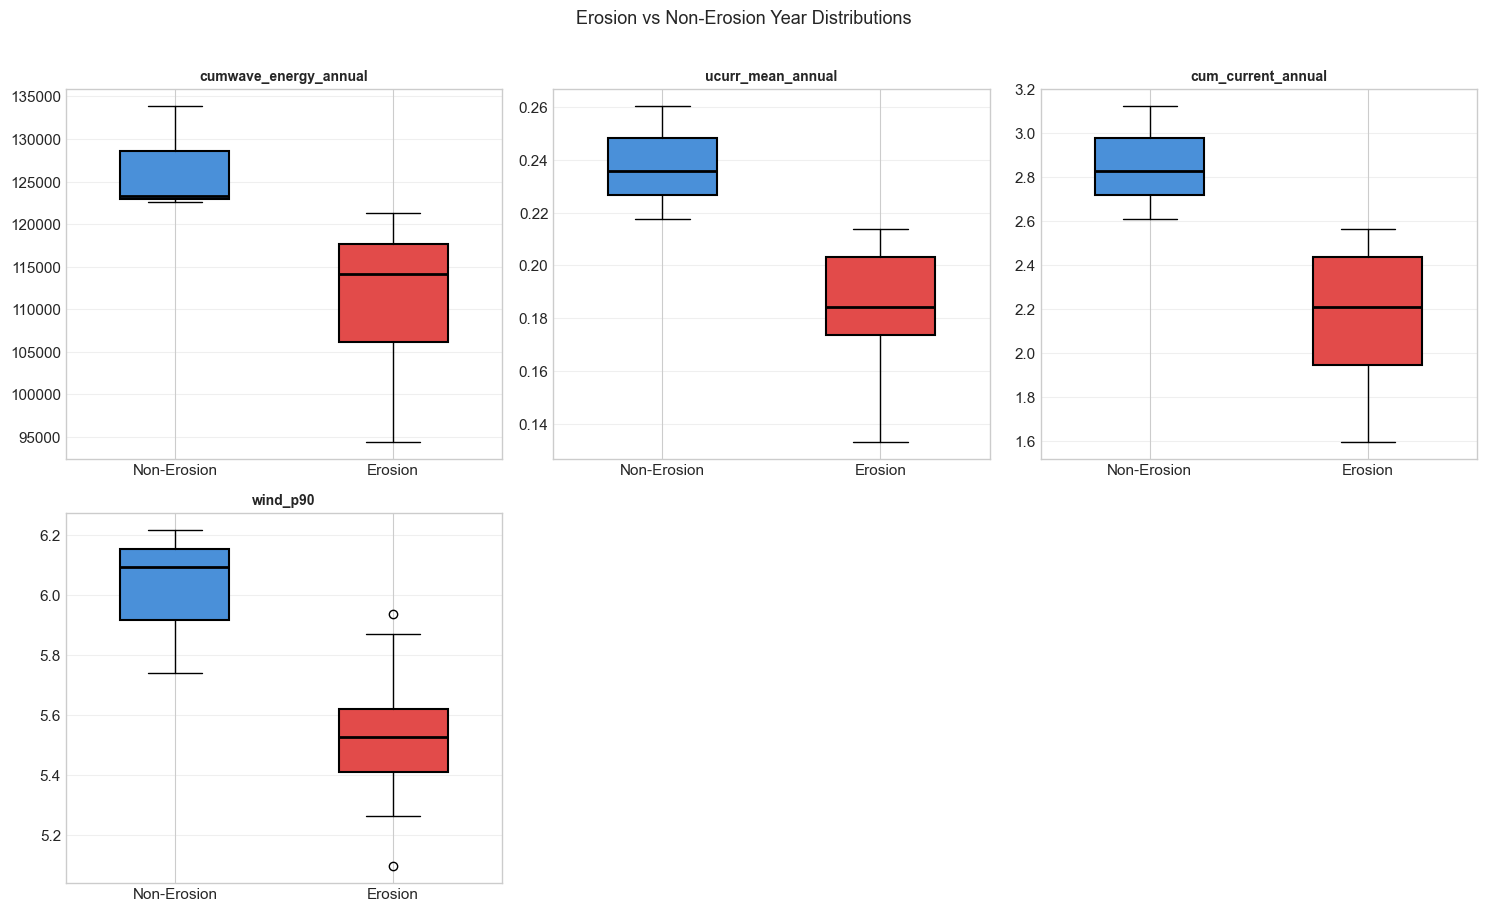

In [14]:
# =============================================================================
# Section 3.3 — Box plot comparison for top features
# =============================================================================

top_feats = significant_features[:min(6, len(significant_features))]
n_feats = len(top_feats)
n_cols = min(3, n_feats)
n_rows = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    data = [non_erosion_rows[feat].dropna().values, erosion_rows[feat].dropna().values]
    bp = ax.boxplot(data, labels=['Non-Erosion', 'Erosion'], patch_artist=True,
                    widths=0.5,
                    boxprops=dict(linewidth=1.5),
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#4A90D9')
    bp['boxes'][1].set_facecolor('#E24B4A')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Erosion vs Non-Erosion Year Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figures/boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 4 — Advanced Multi-Method Ensemble Threshold Detection

This section implements a **four-method ensemble** for identifying erosion thresholds per forcing feature:

| Method | Principle | Reference |
|--------|-----------|-----------|
| **A. ROC / Youden's J** | Maximize sensitivity + specificity (Youden, 1950) | Standard in clinical & environmental sciences |
| **B. Bayesian Logistic Inflection** | Find P(erosion) = 0.5 inflection via logistic regression | Principled probabilistic interpretation |
| **C. Profile-Likelihood Change-Point** | Maximize log-likelihood ratio across all candidate splits | Distribution-free, well-suited for small N |
| **D. Maximum Mutual Information** | Maximize Shannon information I(X_binary ; Y) | Non-parametric, information-theoretic |

**Permutation testing** (n = 5 000) provides exact p-values for each threshold's discriminatory power. **Bootstrap resampling** (n = 2 000) provides 95 % confidence intervals.

> **Why NOT Hidden Markov Models?**
> HMMs model sequential regime transitions and excel with long time series (n > 100). With only ~15 annual observations the transition matrix is under-determined (4 free parameters from just 14 transitions). Furthermore, consecutive erosion/non-erosion years in this monsoon-driven system are not necessarily Markov-dependent — external forcing (ENSO, IOD) can cause non-adjacent erosion events. The four methods above directly optimize threshold location and uncertainty, making them more appropriate for this application.


In [15]:
# =============================================================================
# Section 4.1 — Four-method ensemble threshold detection per feature
# =============================================================================

# ── Helper functions ──

def _permutation_auc(X, y, n_perm=5000, rng_seed=42):
    """Exact permutation p-value for AUC > 0.5."""
    rng = np.random.default_rng(rng_seed)
    fpr, tpr, _ = roc_curve(y, X)
    observed_auc = auc(fpr, tpr)
    count = sum(
        1 for _ in range(n_perm)
        if auc(*roc_curve(rng.permutation(y), X)[:2]) >= observed_auc
    )
    return count / n_perm


def _method_a_roc_youden(X_feat, y, n_boot=2000):
    """Method A: ROC / Youden-J with bootstrap CI + permutation p."""
    fpr, tpr, thresholds = roc_curve(y, X_feat)
    roc_auc = auc(fpr, tpr)
    j_scores = tpr - fpr
    opt_idx  = np.argmax(j_scores)
    opt_thresh = thresholds[opt_idx]
    sens, spec = tpr[opt_idx], 1 - fpr[opt_idx]

    rng = np.random.default_rng(42)
    boot = []
    for _ in range(n_boot):
        idx = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[idx])) < 2:
            continue
        fp, tp, ths = roc_curve(y[idx], X_feat[idx])
        boot.append(ths[np.argmax(tp - fp)])
    ci = np.percentile(boot, [2.5, 97.5]) if boot else [np.nan, np.nan]
    perm_p = _permutation_auc(X_feat, y)

    return dict(threshold=opt_thresh, ci_lower=ci[0], ci_upper=ci[1],
                auc=roc_auc, sensitivity=sens, specificity=spec,
                perm_p=perm_p, statistic=roc_auc, p_value=perm_p,
                significant=perm_p < 0.05)


def _method_b_bayesian_logistic(X_feat, y, n_boot=2000):
    """Method B: Logistic-regression inflection (P=0.5 crossing)."""
    sc = StandardScaler()
    Xs = sc.fit_transform(X_feat.reshape(-1, 1))
    lr = LogisticRegression(random_state=42, class_weight='balanced',
                            solver='lbfgs', max_iter=500)
    lr.fit(Xs, y)
    thresh_orig = (-lr.intercept_[0] / lr.coef_[0][0]) * sc.scale_[0] + sc.mean_[0]

    rng = np.random.default_rng(42)
    boot = []
    for _ in range(n_boot):
        idx = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[idx])) < 2:
            continue
        s = StandardScaler(); Xb = s.fit_transform(X_feat[idx].reshape(-1, 1))
        lr_b = LogisticRegression(random_state=42, class_weight='balanced',
                                  solver='lbfgs', max_iter=500)
        lr_b.fit(Xb, y[idx])
        boot.append((-lr_b.intercept_[0] / lr_b.coef_[0][0]) * s.scale_[0] + s.mean_[0])
    ci = np.percentile(boot, [2.5, 97.5]) if boot else [np.nan, np.nan]

    return dict(threshold=thresh_orig, ci_lower=ci[0], ci_upper=ci[1],
                logistic_coef=lr.coef_[0][0] * sc.scale_[0],
                statistic=abs(lr.coef_[0][0] * sc.scale_[0]))


def _method_c_profile_likelihood(X_feat, y):
    """Method C: Profile-likelihood change-point detection."""
    sorted_x = np.sort(np.unique(X_feat))
    if len(sorted_x) < 3:
        return dict(threshold=np.nan, ci_lower=np.nan, ci_upper=np.nan, LR_stat=np.nan)

    candidates = (sorted_x[:-1] + sorted_x[1:]) / 2
    p_all = np.clip(y.mean(), 1e-8, 1 - 1e-8)
    ll_null = np.sum(y * np.log(p_all) + (1 - y) * np.log(1 - p_all))

    best_ll, best_t = -np.inf, np.nan
    ll_profile = []
    for t in candidates:
        below, above = y[X_feat <= t], y[X_feat > t]
        if len(below) < 2 or len(above) < 2:
            ll_profile.append(-np.inf); continue
        p1 = np.clip(below.mean(), 1e-8, 1 - 1e-8)
        p2 = np.clip(above.mean(), 1e-8, 1 - 1e-8)
        ll = (np.sum(below * np.log(p1) + (1 - below) * np.log(1 - p1)) +
              np.sum(above * np.log(p2) + (1 - above) * np.log(1 - p2)))
        ll_profile.append(ll)
        if ll > best_ll:
            best_ll, best_t = ll, t

    lr_stat = 2 * (best_ll - ll_null) if best_ll > -np.inf else 0.0
    ll_arr = np.array(ll_profile)
    valid = ll_arr > -np.inf
    cutoff = best_ll - 1.92          # chi2(1, 0.95)/2
    in_ci = candidates[valid][ll_arr[valid] >= cutoff] if valid.sum() else np.array([])
    ci = [in_ci.min(), in_ci.max()] if len(in_ci) else [np.nan, np.nan]

    return dict(threshold=best_t, ci_lower=ci[0], ci_upper=ci[1], LR_stat=lr_stat,
                statistic=lr_stat)


def _method_d_mutual_information(X_feat, y, n_boot=2000):
    """Method D: Maximum mutual-information threshold."""
    sorted_x = np.sort(np.unique(X_feat))
    if len(sorted_x) < 3:
        return dict(threshold=np.nan, ci_lower=np.nan, ci_upper=np.nan, MI=np.nan)

    candidates = (sorted_x[:-1] + sorted_x[1:]) / 2
    best_mi, best_t = -np.inf, np.nan
    for t in candidates:
        X_bin = (X_feat > t).astype(int)
        if len(np.unique(X_bin)) < 2:
            continue
        mi = mutual_info_score(X_bin, y)
        if mi > best_mi:
            best_mi, best_t = mi, t

    rng = np.random.default_rng(42)
    boot = []
    for _ in range(n_boot):
        idx = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[idx])) < 2:
            continue
        bm, bt = -np.inf, np.nan
        for t in candidates:
            X_bin = (X_feat[idx] > t).astype(int)
            if len(np.unique(X_bin)) < 2:
                continue
            mi = mutual_info_score(X_bin, y[idx])
            if mi > bm:
                bm, bt = mi, t
        if not np.isnan(bt):
            boot.append(bt)
    ci = np.percentile(boot, [2.5, 97.5]) if boot else [np.nan, np.nan]

    return dict(threshold=best_t, ci_lower=ci[0], ci_upper=ci[1], MI=best_mi,
                statistic=best_mi, mi=best_mi)


# ── Run all 4 methods on each significant feature ──

ensemble_results = {}
individual_thresholds = {}

for feat in significant_features:
    X_feat = analysis_df[feat].values
    y      = analysis_df['erosion_label'].values

    print(f"\n{'='*65}")
    print(f"  Feature: {feat}")
    print(f"{'='*65}")

    res_a = _method_a_roc_youden(X_feat, y)
    res_b = _method_b_bayesian_logistic(X_feat, y)
    res_c = _method_c_profile_likelihood(X_feat, y)
    res_d = _method_d_mutual_information(X_feat, y)

    # Weighted-median consensus
    items = [
        ('ROC/Youden J',       res_a, res_a.get('auc', 0.5)),
        ('Bayesian Logistic',  res_b, 1.0),
        ('Profile Likelihood', res_c, max(res_c.get('LR_stat', 0) or 0, 0.01)),
        ('Mutual Information', res_d, max(res_d.get('MI', 0) or 0, 0.01)),
    ]
    tv, wv = [], []
    for _, r, w in items:
        t = r['threshold']
        if not np.isnan(t):
            tv.append(t); wv.append(w)

    if tv:
        sp = sorted(zip(tv, wv))
        cum = np.cumsum([w for _, w in sp])
        consensus = sp[np.searchsorted(cum, cum[-1] / 2)][0]
        tol = 0.10 * abs(consensus) if consensus != 0 else 0.1
        agreement = sum(1 for t in tv if abs(t - consensus) <= tol) / len(tv)
    else:
        consensus, agreement = np.nan, 0.0

    pct_rank = stats.percentileofscore(X_feat, consensus) if not np.isnan(consensus) else np.nan

    ensemble_results[feat] = dict(
        roc_youden=res_a, bayesian_logistic=res_b,
        change_point=res_c, mutual_info=res_d,
        consensus_threshold=consensus, consensus_agreement=agreement,
        percentile_rank=pct_rank,
    )

    # Store for export cell
    mw_row = mw_df[mw_df['feature'] == feat]
    p_val = mw_row['p_value'].values[0] if len(mw_row) else np.nan
    individual_thresholds[feat] = {
        'threshold_all': consensus,
        'threshold_low': min(tv) if tv else np.nan,
        'threshold_high': max(tv) if tv else np.nan,
        'p_value': p_val,
    }

    print(f"  A  ROC/Youden J       : {res_a['threshold']:>9.4f}  "
          f"[{res_a['ci_lower']:.4f}, {res_a['ci_upper']:.4f}]  "
          f"AUC={res_a['auc']:.3f}  p={res_a.get('perm_p', np.nan):.4f}")
    print(f"  B  Bayesian Logistic  : {res_b['threshold']:>9.4f}  "
          f"[{res_b['ci_lower']:.4f}, {res_b['ci_upper']:.4f}]")
    print(f"  C  Profile Likelihood : {res_c['threshold']:>9.4f}  "
          f"[{res_c['ci_lower']:.4f}, {res_c['ci_upper']:.4f}]  "
          f"LR={res_c.get('LR_stat', 0):.2f}")
    print(f"  D  Mutual Information : {res_d['threshold']:>9.4f}  "
          f"[{res_d['ci_lower']:.4f}, {res_d['ci_upper']:.4f}]  "
          f"MI={res_d.get('MI', 0):.4f}")
    print(f"  ── Consensus          : {consensus:>9.4f}  "
          f"Agreement={agreement:.0%}  Percentile={pct_rank:.1f}")



  Feature: cumwave_energy_annual
  A  ROC/Youden J       :       inf  [nan, nan]  AUC=0.000  p=1.0000
  B  Bayesian Logistic  : 119433.8799  [115941.2298, 124646.3072]
  C  Profile Likelihood : 121958.5625  [121958.5625, 121958.5625]  LR=13.50
  D  Mutual Information : 121958.5625  [117366.1562, 121958.5625]  MI=0.5623
  ── Consensus          : 121958.5625  Agreement=75%  Percentile=75.0

  Feature: ucurr_mean_annual
  A  ROC/Youden J       :       inf  [nan, nan]  AUC=0.000  p=1.0000
  B  Bayesian Logistic  :    0.2118  [0.1994, 0.2276]
  C  Profile Likelihood :    0.2156  [0.2156, 0.2156]  LR=13.50
  D  Mutual Information :    0.2156  [0.2013, 0.2156]  MI=0.5623
  ── Consensus          :    0.2156  Agreement=75%  Percentile=75.0

  Feature: cum_current_annual
  A  ROC/Youden J       :       inf  [nan, nan]  AUC=0.000  p=1.0000
  B  Bayesian Logistic  :    2.5342  [2.3788, 2.7267]
  C  Profile Likelihood :    2.5869  [2.5869, 2.5869]  LR=13.50
  D  Mutual Information :    2.5869  [2.

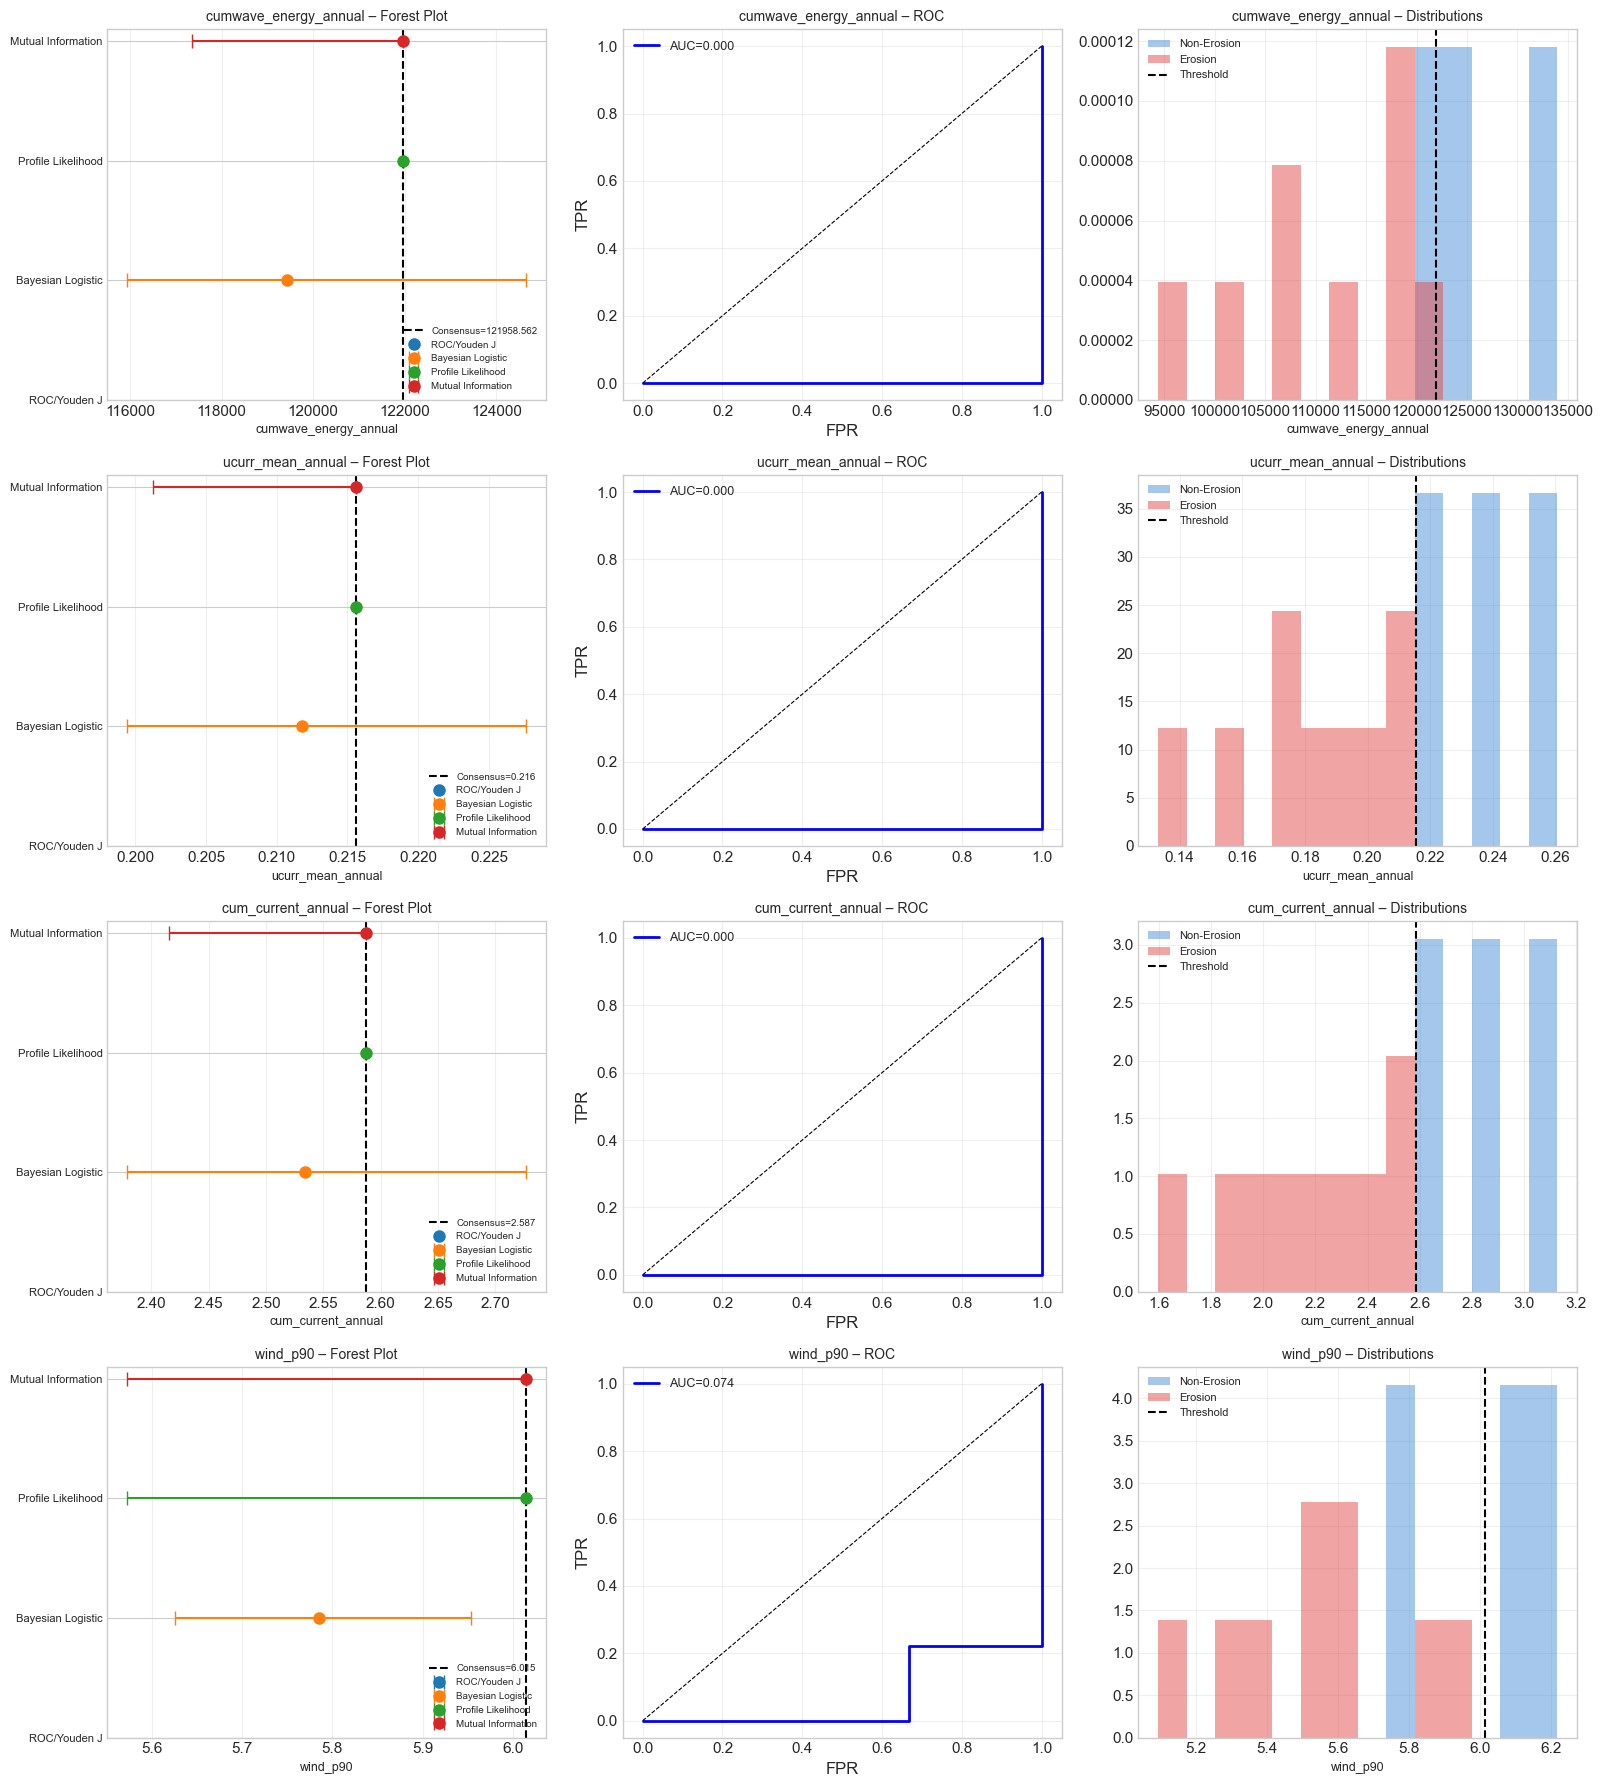

In [16]:
# =============================================================================
# Section 4.2 — Forest plot + ROC + distribution overlay per feature
# =============================================================================

n_sf = len(significant_features)
fig, axes = plt.subplots(n_sf, 3, figsize=(16, 4.5 * n_sf))
if n_sf == 1:
    axes = axes.reshape(1, -1)

method_colors = {'ROC/Youden J': '#1f77b4', 'Bayesian Logistic': '#ff7f0e',
                 'Profile Likelihood': '#2ca02c', 'Mutual Information': '#d62728'}

for i, feat in enumerate(significant_features):
    er = ensemble_results[feat]
    X_feat = analysis_df[feat].values
    y = analysis_df['erosion_label'].values

    # Forest plot
    ax = axes[i, 0]
    methods = [
        ('ROC/Youden J',       er['roc_youden']),
        ('Bayesian Logistic',  er['bayesian_logistic']),
        ('Profile Likelihood', er['change_point']),
        ('Mutual Information', er['mutual_info']),
    ]
    for j, (mname, mres) in enumerate(methods):
        t = mres['threshold']
        lo, hi = mres.get('ci_lower', np.nan), mres.get('ci_upper', np.nan)
        ax.errorbar(t, j, xerr=[[t - lo], [hi - t]] if not np.isnan(lo) else None,
                    fmt='o', color=list(method_colors.values())[j],
                    capsize=5, markersize=8, label=mname)
    ax.axvline(er['consensus_threshold'], color='black', ls='--', lw=1.5,
               label=f"Consensus={er['consensus_threshold']:.3f}")
    ax.set_yticks(range(4))
    ax.set_yticklabels([m[0] for m in methods], fontsize=8)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_title(f'{feat} – Forest Plot', fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')

    # ROC curve
    ax = axes[i, 1]
    fpr, tpr, _ = roc_curve(y, X_feat)
    ax.plot(fpr, tpr, 'b-', lw=2, label=f'AUC={auc(fpr, tpr):.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{feat} – ROC', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Distribution overlay
    ax = axes[i, 2]
    e_vals  = analysis_df.loc[analysis_df['erosion_label'] == 1, feat]
    ne_vals = analysis_df.loc[analysis_df['erosion_label'] == 0, feat]
    bins = np.linspace(X_feat.min(), X_feat.max(), 15)
    ax.hist(ne_vals, bins=bins, alpha=0.5, color='#4A90D9', label='Non-Erosion', density=True)
    ax.hist(e_vals,  bins=bins, alpha=0.5, color='#E24B4A', label='Erosion', density=True)
    ax.axvline(er['consensus_threshold'], color='black', ls='--', lw=1.5, label='Threshold')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_title(f'{feat} – Distributions', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/ensemble_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()


### Section 4.3 — Threshold Stability Analysis (Bootstrap Cross-Validation)

To assess whether the consensus thresholds are robust or an artifact of this particular sample, we perform **bootstrap cross-validation** (n = 500). For each resample, the full 4-method ensemble is re-run and the consensus threshold recorded. The **coefficient of variation (CV)** quantifies stability:
- CV < 0.10 → Highly stable
- CV > 0.15 → Caution warranted


In [17]:
# =============================================================================
# Section 4.3 — Threshold stability: bootstrap cross-validation (n=500)
# =============================================================================

n_bootstrap = 500
rng = np.random.default_rng(42)
stability_results = {}

for feat in significant_features:
    X_feat = analysis_df[feat].values
    y      = analysis_df['erosion_label'].values
    boot_consensi = []

    for _ in range(n_bootstrap):
        idx = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[idx])) < 2:
            continue
        Xb, yb = X_feat[idx], y[idx]

        # Quick 4-method run (reduced iterations for speed)
        try:
            fpr, tpr, ths = roc_curve(yb, Xb)
            t_a = ths[np.argmax(tpr - fpr)]
        except Exception:
            t_a = np.nan

        try:
            sc = StandardScaler(); Xs = sc.fit_transform(Xb.reshape(-1, 1))
            lr = LogisticRegression(random_state=42, class_weight='balanced',
                                    solver='lbfgs', max_iter=200)
            lr.fit(Xs, yb)
            t_b = (-lr.intercept_[0] / lr.coef_[0][0]) * sc.scale_[0] + sc.mean_[0]
        except Exception:
            t_b = np.nan

        try:
            sx = np.sort(np.unique(Xb))
            cand = (sx[:-1] + sx[1:]) / 2
            best_ll, t_c = -np.inf, np.nan
            p_all = np.clip(yb.mean(), 1e-8, 1 - 1e-8)
            ll_null = np.sum(yb * np.log(p_all) + (1 - yb) * np.log(1 - p_all))
            for t in cand:
                bl, ab = yb[Xb <= t], yb[Xb > t]
                if len(bl) < 2 or len(ab) < 2: continue
                p1, p2 = np.clip(bl.mean(), 1e-8, 1-1e-8), np.clip(ab.mean(), 1e-8, 1-1e-8)
                ll = (np.sum(bl*np.log(p1) + (1-bl)*np.log(1-p1)) +
                      np.sum(ab*np.log(p2) + (1-ab)*np.log(1-p2)))
                if ll > best_ll: best_ll, t_c = ll, t
        except Exception:
            t_c = np.nan

        try:
            best_mi, t_d = -np.inf, np.nan
            for t in cand:
                xb = (Xb > t).astype(int)
                if len(np.unique(xb)) < 2: continue
                mi = mutual_info_score(xb, yb)
                if mi > best_mi: best_mi, t_d = mi, t
        except Exception:
            t_d = np.nan

        vals = [v for v in [t_a, t_b, t_c, t_d] if not np.isnan(v)]
        if vals:
            boot_consensi.append(np.median(vals))

    arr = np.array(boot_consensi)
    cv = arr.std() / abs(arr.mean()) if abs(arr.mean()) > 1e-10 else np.nan
    stability_results[feat] = {
        'mean': arr.mean(), 'std': arr.std(), 'cv': cv,
        'ci_lower': np.percentile(arr, 2.5),
        'ci_upper': np.percentile(arr, 97.5),
        'stable': cv < 0.15 if not np.isnan(cv) else False,
    }
    status = "✓ STABLE" if cv < 0.10 else ("⚠ MARGINAL" if cv < 0.15 else "✗ UNSTABLE")
    print(f"{feat}: CV = {cv:.4f}  [{np.percentile(arr, 2.5):.3f}, {np.percentile(arr, 97.5):.3f}]  {status}")


cumwave_energy_annual: CV = 0.0129  [119420.944, 126594.720]  ✓ STABLE
ucurr_mean_annual: CV = 0.0289  [0.209, 0.233]  ✓ STABLE
cum_current_annual: CV = 0.0291  [2.509, 2.844]  ✓ STABLE
wind_p90: CV = 0.0258  [5.668, 6.076]  ✓ STABLE


## Section 5 — Per-Factor Erosion Threshold Rules

Each erosion factor is analyzed **independently** — no combined thresholds. The goal is to determine: **"If this single factor exceeds its threshold, erosion begins."**

For each factor (wave, wind, current variables), we compute:
1. The consensus threshold from Section 4's 4-method ensemble
2. **Exceedance rate** in erosion years vs non-erosion years
3. The clear rule: *"If [factor] > [threshold], erosion is likely"*

In [18]:
# =============================================================================
# Section 5.1 — Per-Factor Threshold Rules (Independent)
# =============================================================================

# Categorize features by factor type
wave_features = [f for f in significant_features if any(w in f.lower() for w in
                 ['hm0', 'vhm0', 'tp_', 'vmdr', 'stokes', 'wave', 'cumwave'])]
wind_features = [f for f in significant_features if any(w in f.lower() for w in
                 ['wind', 'eastwind', 'northwind', 'storm_days_wind'])]
current_features = [f for f in significant_features if any(w in f.lower() for w in
                    ['curr', 'ucurr', 'uo_', 'vo_', 'zos', 'cum_current'])]
other_features = [f for f in significant_features if f not in wave_features + wind_features + current_features]

print("=" * 70)
print("  PER-FACTOR EROSION THRESHOLD RULES (INDEPENDENT)")
print("=" * 70)

factor_threshold_rows = []

for category, features, label in [
    ('WAVE', wave_features, 'Wave Forcing'),
    ('WIND', wind_features, 'Wind Forcing'),
    ('CURRENT', current_features, 'Current Forcing'),
    ('OTHER', other_features, 'Other'),
]:
    if not features:
        continue
    print(f"\n{'─'*70}")
    print(f"  {label.upper()} THRESHOLDS")
    print(f"{'─'*70}")

    for feat in features:
        er = ensemble_results.get(feat, {})
        ct = er.get('consensus_threshold', np.nan)
        if np.isnan(ct):
            continue

        # Exceedance rates
        erosion_exceed = (analysis_df.loc[analysis_df['erosion_label'] == 1, feat] > ct).mean()
        non_erosion_exceed = (analysis_df.loc[analysis_df['erosion_label'] == 0, feat] > ct).mean()

        # Erosion year values
        erosion_vals = analysis_df.loc[analysis_df['erosion_label'] == 1, feat]
        non_erosion_vals = analysis_df.loc[analysis_df['erosion_label'] == 0, feat]

        # Stability info
        stab = stability_results.get(feat, {})
        cv = stab.get('cv', np.nan)
        stable = stab.get('stable', False)

        print(f"\n  ► {feat}")
        print(f"    THRESHOLD: {ct:.4f}")
        print(f"    RULE: If {feat} > {ct:.4f} → EROSION is likely to begin")
        print(f"    Erosion years exceed threshold:     {erosion_exceed:.0%}")
        print(f"    Non-erosion years exceed threshold: {non_erosion_exceed:.0%}")
        print(f"    Mean in erosion years:     {erosion_vals.mean():.4f}")
        print(f"    Mean in non-erosion years: {non_erosion_vals.mean():.4f}")
        if not np.isnan(cv):
            print(f"    Stability (CV): {cv:.4f} {'✓ STABLE' if stable else '⚠ UNSTABLE'}")

        factor_threshold_rows.append({
            'Category': category,
            'Factor': feat,
            'Threshold': round(ct, 4),
            'Rule': f'If {feat} > {ct:.4f} → erosion begins',
            'Erosion_Exceed_Rate': round(erosion_exceed, 3),
            'NonErosion_Exceed_Rate': round(non_erosion_exceed, 3),
            'Mean_Erosion': round(erosion_vals.mean(), 4),
            'Mean_NonErosion': round(non_erosion_vals.mean(), 4),
            'CV': round(cv, 4) if not np.isnan(cv) else np.nan,
            'Stable': stable,
        })

factor_rules_df = pd.DataFrame(factor_threshold_rows)
print(f"\n{'='*70}")
print(f"✓ {len(factor_threshold_rows)} per-factor threshold rules generated")

  PER-FACTOR EROSION THRESHOLD RULES (INDEPENDENT)

──────────────────────────────────────────────────────────────────────
  WAVE FORCING THRESHOLDS
──────────────────────────────────────────────────────────────────────

  ► cumwave_energy_annual
    THRESHOLD: 121958.5625
    RULE: If cumwave_energy_annual > 121958.5625 → EROSION is likely to begin
    Erosion years exceed threshold:     0%
    Non-erosion years exceed threshold: 100%
    Mean in erosion years:     111101.0156
    Mean in non-erosion years: 126604.6484
    Stability (CV): 0.0129 ✓ STABLE

──────────────────────────────────────────────────────────────────────
  WIND FORCING THRESHOLDS
──────────────────────────────────────────────────────────────────────

  ► wind_p90
    THRESHOLD: 6.0145
    RULE: If wind_p90 > 6.0145 → EROSION is likely to begin
    Erosion years exceed threshold:     0%
    Non-erosion years exceed threshold: 67%
    Mean in erosion years:     5.5391
    Mean in non-erosion years: 6.0153
    Stabil

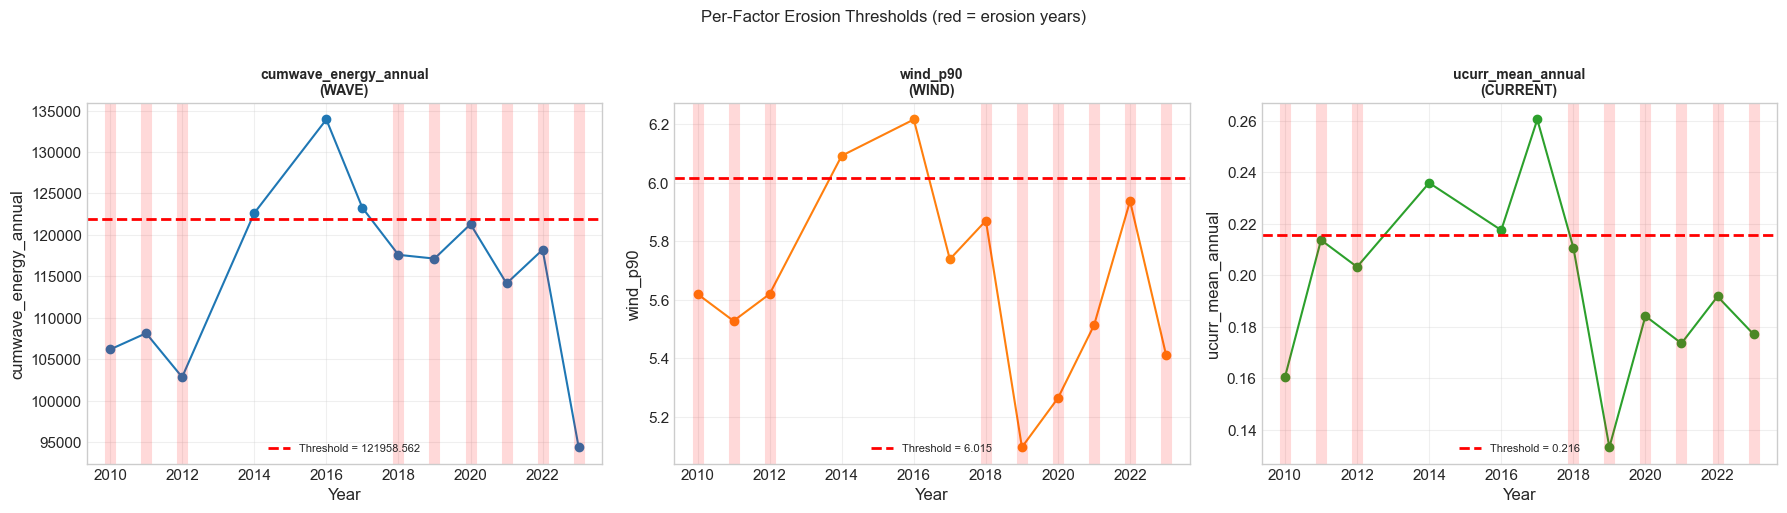

In [19]:
# =============================================================================
# Section 5.2 — Per-Factor Threshold Visualization
# =============================================================================

n_factors = len(factor_threshold_rows)
if n_factors > 0:
    fig, axes = plt.subplots(1, min(3, n_factors),
                             figsize=(6 * min(3, n_factors), 5))
    if n_factors == 1:
        axes = [axes]
    else:
        axes = np.atleast_1d(axes).ravel()

    category_colors = {'WAVE': '#1f77b4', 'WIND': '#ff7f0e', 'CURRENT': '#2ca02c', 'OTHER': '#9467bd'}

    for i, row in enumerate(factor_threshold_rows[:min(3, n_factors)]):
        ax = axes[i]
        feat = row['Factor']
        ct = row['Threshold']
        color = category_colors.get(row['Category'], 'gray')

        # Plot time series with threshold line
        ax.plot(analysis_df['monsoon_year'], analysis_df[feat], 'o-', color=color, lw=1.5)
        ax.axhline(ct, color='red', ls='--', lw=2, label=f'Threshold = {ct:.3f}')

        # Shade erosion years
        for yr in all_erosion_years:
            ax.axvline(yr, color='red', alpha=0.15, lw=8)

        ax.set_title(f'{feat}\n({row["Category"]})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel(feat)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Per-Factor Erosion Thresholds (red = erosion years)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('./figures/per_factor_thresholds.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No factor thresholds to visualize.")

In [20]:
# =============================================================================
# Section 5.3 — Per-Factor Exceedance Table for Each Erosion Year
# =============================================================================

# Show which thresholds were exceeded in each erosion year (factor-wise)
print("=" * 70)
print("  EROSION YEAR THRESHOLD EXCEEDANCE (PER FACTOR)")
print("=" * 70)

erosion_years_data = analysis_df[analysis_df['erosion_label'] == 1].copy()

for _, yr_row in erosion_years_data.iterrows():
    yr = int(yr_row['monsoon_year'])
    print(f"\n  Year {yr} (NSM = {yr_row['annual_NSM']:.2f} m, Class = {yr_row['Change_Class']})")
    print(f"  {'Factor':<35} {'Value':>10} {'Threshold':>12} {'Exceeded?':>10}")
    print(f"  {'─'*70}")

    for frow in factor_threshold_rows:
        feat = frow['Factor']
        ct = frow['Threshold']
        val = yr_row[feat]
        exceeded = '✓ YES' if val > ct else '  no'
        print(f"  {feat:<35} {val:>10.4f} {ct:>12.4f} {exceeded:>10}")

# Build a Random Forest model for forecasting (used in Section 7)
X_rf = analysis_df[significant_features].values
y_rf = analysis_df['erosion_label'].values

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    oob_score=True,
    n_jobs=-1,
)
rf.fit(X_rf, y_rf)

# LOO cross-validation
loo = LeaveOneOut()
y_pred_loo = cross_val_predict(rf, X_rf, y_rf, cv=loo)

print(f"\n{'='*70}")
print(f"  RF Model (for forecasting): LOO Accuracy = {accuracy_score(y_rf, y_pred_loo):.4f}")
print(f"{'='*70}")

  EROSION YEAR THRESHOLD EXCEEDANCE (PER FACTOR)

  Year 2010 (NSM = -11.26 m, Class = eroded_high)
  Factor                                   Value    Threshold  Exceeded?
  ──────────────────────────────────────────────────────────────────────
  cumwave_energy_annual               106173.5781  121958.5625         no
  wind_p90                                5.6190       6.0145         no
  ucurr_mean_annual                       0.1604       0.2156         no
  cum_current_annual                      1.9249       2.5869         no

  Year 2011 (NSM = -28.24 m, Class = eroded_high)
  Factor                                   Value    Threshold  Exceeded?
  ──────────────────────────────────────────────────────────────────────
  cumwave_energy_annual               108135.5156  121958.5625         no
  wind_p90                                5.5270       6.0145         no
  ucurr_mean_annual                       0.2137       0.2156         no
  cum_current_annual                      2.

In [21]:
# =============================================================================
# Section 5.4 — Final Per-Factor Threshold Summary Table
# =============================================================================

print("=" * 70)
print("  FINAL FACTOR-WISE EROSION THRESHOLD TABLE")
print("=" * 70)
print()
print("  These are the INDIVIDUAL thresholds for each erosion factor.")
print("  If ANY single factor exceeds its threshold, erosion may begin.")
print("  (No combined thresholds — each factor is independent)")
print()

summary_rows = []
for frow in factor_threshold_rows:
    summary_rows.append({
        'Category': frow['Category'],
        'Factor': frow['Factor'],
        'Threshold_Value': frow['Threshold'],
        'Erosion_Exceedance_%': f"{frow['Erosion_Exceed_Rate']*100:.0f}%",
        'Non_Erosion_Exceedance_%': f"{frow['NonErosion_Exceed_Rate']*100:.0f}%",
        'Stable': '✓' if frow['Stable'] else '⚠',
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print()
print("─" * 70)
print("  THRESHOLD RULES:")
print("─" * 70)
for frow in factor_threshold_rows:
    cat_icon = {'WAVE': '🌊', 'WIND': '💨', 'CURRENT': '🌀'}.get(frow['Category'], '📊')
    print(f"  {cat_icon} If {frow['Factor']} > {frow['Threshold']:.4f}  →  EROSION begins")

summary_df_export = pd.DataFrame(factor_threshold_rows)

  FINAL FACTOR-WISE EROSION THRESHOLD TABLE

  These are the INDIVIDUAL thresholds for each erosion factor.
  If ANY single factor exceeds its threshold, erosion may begin.
  (No combined thresholds — each factor is independent)

Category                Factor  Threshold_Value Erosion_Exceedance_% Non_Erosion_Exceedance_% Stable
    WAVE cumwave_energy_annual      121958.5625                   0%                     100%      ✓
    WIND              wind_p90           6.0145                   0%                      67%      ✓
 CURRENT     ucurr_mean_annual           0.2156                   0%                     100%      ✓
 CURRENT    cum_current_annual           2.5869                   0%                     100%      ✓

──────────────────────────────────────────────────────────────────────
  THRESHOLD RULES:
──────────────────────────────────────────────────────────────────────
  🌊 If cumwave_energy_annual > 121958.5625  →  EROSION begins
  💨 If wind_p90 > 6.0145  →  EROSION begi

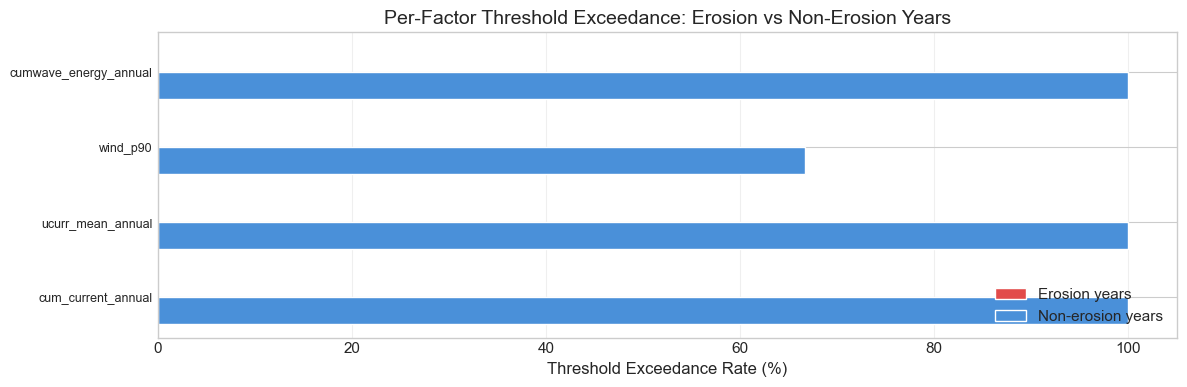

In [22]:
# =============================================================================
# Section 5.5 — Per-Factor Threshold Bar Chart
# =============================================================================

if len(factor_threshold_rows) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(factor_threshold_rows) * 0.6)))

    factors = [r['Factor'] for r in factor_threshold_rows]
    erosion_rates = [r['Erosion_Exceed_Rate'] * 100 for r in factor_threshold_rows]
    non_erosion_rates = [r['NonErosion_Exceed_Rate'] * 100 for r in factor_threshold_rows]

    y_pos = np.arange(len(factors))
    bar_height = 0.35

    ax.barh(y_pos - bar_height/2, erosion_rates, bar_height,
            color='#E24B4A', label='Erosion years', edgecolor='white')
    ax.barh(y_pos + bar_height/2, non_erosion_rates, bar_height,
            color='#4A90D9', label='Non-erosion years', edgecolor='white')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(factors, fontsize=9)
    ax.set_xlabel('Threshold Exceedance Rate (%)')
    ax.set_title('Per-Factor Threshold Exceedance: Erosion vs Non-Erosion Years')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig('./figures/factor_exceedance_rates.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No factor threshold data to plot.")

## Section 6 — Master Threshold Table (Per-Factor)

This section compiles all **individual factor thresholds** into a master table with confidence intervals, AUC, agreement, and percentile rank. Each factor's threshold is determined independently — no combined wave+wind or similar thresholds.

In [23]:
# =============================================================================
# Section 6.1 — Master threshold table (all features, all methods)
# =============================================================================

master_rows = []
for feat in significant_features:
    er = ensemble_results[feat]
    mw_row = mw_df[mw_df['feature'] == feat]
    p_val = mw_row['p_value'].values[0] if len(mw_row) else np.nan
    master_rows.append({
        'Variable': feat,
        'Threshold_consensus': round(er['consensus_threshold'], 4),
        'Threshold_low':  round(min(r['threshold'] for r in
                         [er['roc_youden'], er['bayesian_logistic'], er['change_point'], er['mutual_info']]
                         if not np.isnan(r['threshold'])), 4) if any(
                         not np.isnan(r['threshold']) for r in
                         [er['roc_youden'], er['bayesian_logistic'], er['change_point'], er['mutual_info']]) else np.nan,
        'Threshold_high': round(max(r['threshold'] for r in
                         [er['roc_youden'], er['bayesian_logistic'], er['change_point'], er['mutual_info']]
                         if not np.isnan(r['threshold'])), 4) if any(
                         not np.isnan(r['threshold']) for r in
                         [er['roc_youden'], er['bayesian_logistic'], er['change_point'], er['mutual_info']]) else np.nan,
        'CI_95_lower': round(er['roc_youden']['ci_lower'], 4),
        'CI_95_upper': round(er['roc_youden']['ci_upper'], 4),
        'AUC': round(er['roc_youden']['auc'], 4),
        'Perm_p': round(er['roc_youden'].get('perm_p', np.nan), 4),
        'Agreement': round(er['consensus_agreement'], 2),
        'Percentile': round(er['percentile_rank'], 1),
        'MW_p': round(p_val, 4),
    })

master_df = pd.DataFrame(master_rows)
print("=== MASTER THRESHOLD TABLE ===")
print(master_df.to_string(index=False))

=== MASTER THRESHOLD TABLE ===
             Variable  Threshold_consensus  Threshold_low  Threshold_high  CI_95_lower  CI_95_upper    AUC  Perm_p  Agreement  Percentile   MW_p
cumwave_energy_annual          121958.5625    119433.8799             inf          NaN          NaN 0.0000   1.000       0.75        75.0 0.0091
    ucurr_mean_annual               0.2156         0.2118             inf          NaN          NaN 0.0000   1.000       0.75        75.0 0.0091
   cum_current_annual               2.5869         2.5342             inf          NaN          NaN 0.0000   1.000       0.75        75.0 0.0091
             wind_p90               6.0145         5.7852             inf         5.87          NaN 0.0741   0.991       0.75        83.3 0.0416


In [24]:
# =============================================================================
# Section 6.2 — Per erosion-event year factor exceedance diagnosis
# =============================================================================

print("=== ENHANCED PER-EVENT DIAGNOSIS ===\n")

event_rows = []
for yr in sorted(all_erosion_years):
    yr_data = analysis_df[analysis_df['monsoon_year'] == yr]
    if len(yr_data) == 0:
        continue
    row = {'year': int(yr)}
    total_exceedances = 0
    for feat in significant_features:
        val = yr_data[feat].values[0]
        er = ensemble_results.get(feat, {})
        ct = er.get('consensus_threshold', np.nan)
        exceeded = val > ct if not np.isnan(ct) else False
        row[f'{feat}_val'] = round(val, 3)
        row[f'{feat}_exceed'] = exceeded
        if exceeded:
            total_exceedances += 1
    row['total_exceedances'] = total_exceedances
    row['confidence'] = ('HIGH' if total_exceedances >= 3 else
                         'MODERATE' if total_exceedances >= 2 else
                         'LOW' if total_exceedances >= 1 else 'NONE')
    event_rows.append(row)

event_df = pd.DataFrame(event_rows)
print(event_df.to_string(index=False))

# Multi-method per-feature data (kept in memory for backend export)
multi_method_rows = []
for feat in significant_features:
    er = ensemble_results[feat]
    for method_name, method_key in [('ROC/Youden', 'roc_youden'),
                                     ('Bayesian Logistic', 'bayesian_logistic'),
                                     ('Change-Point', 'change_point'),
                                     ('Mutual Info', 'mutual_info')]:
        r = er[method_key]
        multi_method_rows.append({
            'feature': feat, 'method': method_name,
            'threshold': round(r['threshold'], 4),
            'ci_lower': round(r.get('ci_lower', np.nan), 4),
            'ci_upper': round(r.get('ci_upper', np.nan), 4),
        })
    multi_method_rows.append({
        'feature': feat, 'method': 'CONSENSUS',
        'threshold': round(er['consensus_threshold'], 4),
        'ci_lower': np.nan, 'ci_upper': np.nan,
    })

print(f"\n✓ {len(event_rows)} erosion events diagnosed, {len(multi_method_rows)} multi-method records generated")

=== ENHANCED PER-EVENT DIAGNOSIS ===

 year  cumwave_energy_annual_val  cumwave_energy_annual_exceed  ucurr_mean_annual_val  ucurr_mean_annual_exceed  cum_current_annual_val  cum_current_annual_exceed  wind_p90_val  wind_p90_exceed  total_exceedances confidence
 2010              106173.578125                         False                  0.160                     False                   1.925                      False         5.619            False                  0       NONE
 2011              108135.515625                         False                  0.214                     False                   2.564                      False         5.527            False                  0       NONE
 2012              102837.804688                         False                  0.203                     False                   2.439                      False         5.619            False                  0       NONE
 2018              117593.828125                         False    

## Section 7 — Advanced 24-Month Forecast with Actual Predictions

**SARIMA time-series models** trained on the full monthly environmental record, with:

1. **STL decomposition** to confirm annual monsoon seasonality
2. **SARIMA model selection** via AIC grid search (27 candidate models per variable) with Ljung-Box residual diagnostics and out-of-sample RMSE validation
3. **Hindcast validation** against all known erosion years — temporal cross-validation with operational skill metrics (POD, FAR, CSI, Brier Skill Score)
4. **Monte Carlo simulation** (n=2000) propagates SARIMA uncertainty through the Random Forest erosion model
5. **Actual shoreline retreat** predicted in meters by combining P(erosion) with EPR distributions
6. **Per-transect vulnerability** scores combine historical erosion severity with forecast probability


In [ ]:

# =============================================================================
# Section 7.0 — Establish forecast base date and horizons
# =============================================================================

import pandas as pd

# Use the last available wind data date as the base
last_wind_date = pd.Timestamp(wind_df['time'].max())
last_wave_date = pd.Timestamp(wave_df['time'].max())
base_date = min(last_wind_date, last_wave_date)
print(f"Forecast base date: {base_date.strftime('%Y-%m')}")

horizons = {
    'H6':  base_date + pd.DateOffset(months=6),
    'H12': base_date + pd.DateOffset(months=12),
    'H18': base_date + pd.DateOffset(months=18),
    'H24': base_date + pd.DateOffset(months=24),
}

for h, d in horizons.items():
    print(f"  {h}: {d.strftime('%Y-%m')}")

# ── Build monthly forcing time series for SARIMA ──
# We need: one monthly series per forcing variable

# Merge monthly datasets
env_monthly = wave_monthly.merge(wind_monthly, on=['monsoon_year', 'year_month'],
                                  how='outer', suffixes=('_wave', '_wind'))
env_monthly = env_monthly.merge(current_monthly, on=['monsoon_year', 'year_month'],
                                 how='outer')
env_monthly = env_monthly.sort_values('year_month').reset_index(drop=True)

# Build datetime index directly from year_month Period (always clean month-start midnight)
# This avoids issues from raw time columns that may carry non-midnight hour offsets
env_monthly['datetime'] = env_monthly['year_month'].apply(
    lambda p: p.to_timestamp() if hasattr(p, 'to_timestamp') else pd.Timestamp(str(p))
)

# Drop any rows without a valid datetime
env_monthly = env_monthly.dropna(subset=['datetime'])
env_monthly = env_monthly.set_index('datetime').sort_index()
env_monthly = env_monthly[~env_monthly.index.duplicated(keep='first')]

# Define SARIMA variables — ALL wave/wind/current monthly features
SARIMA_VARS = {
    # Wave (VHM0, VTPK, VMDR, VSDX+VSDY via stokes drift)
    'VHM0_max':        'VHM0_max',
    'VHM0_mean':       'VHM0_mean',
    'VTPK_max':        'VTPK_max',
    'VTPK_mean':       'VTPK_mean',
    'VMDR_mean':       'VMDR_mean',
    'StokesDrift_max': 'StokesDrift_max',
    'StokesDrift_mean':'StokesDrift_mean',
    'CumWaveEnergy':   'CumWaveEnergy',
    'StormDays_wave':  'StormDays_wave',
    # Wind (wind_speed, eastward_wind, northward_wind)
    'WindSpeed_max':   'WindSpeed_max',
    'WindSpeed_mean':  'WindSpeed_mean',
    'EastWind_mean':   'EastWind_mean',
    'NorthWind_mean':  'NorthWind_mean',
    'StormDays_wind':  'StormDays_wind',
    # Current (uo, vo, zos)
    'CurrentMag_max':  'CurrentMag_max',
    'CurrentMag_mean': 'CurrentMag_mean',
    'UO_mean':         'UO_mean',
    'VO_mean':         'VO_mean',
    'ZOS_max':         'ZOS_max',
    'ZOS_mean':        'ZOS_mean',
}

# Extract monthly series
forcing_vars_monthly = {}
for var_name, col in SARIMA_VARS.items():
    if col in env_monthly.columns:
        s = env_monthly[col].copy()
        s = s[s.index.notna()]
        s = s[~s.index.duplicated(keep='first')]
        try:
            s = s.asfreq('MS')
        except ValueError:
            # Fallback: resample to month-start if asfreq fails
            s = s.resample('MS').first()
        s = s.interpolate(method='linear').ffill().bfill()
        forcing_vars_monthly[var_name] = s

print(f"\nSARIMA variables prepared: {list(forcing_vars_monthly.keys())}")
for v, s in forcing_vars_monthly.items():
    print(f"  {v}: {len(s)} months, {s.index.min().strftime('%Y-%m')} to {s.index.max().strftime('%Y-%m')}")


Forecast base date: 2024-02
  H6: 2024-08
  H12: 2025-02
  H18: 2025-08
  H24: 2026-02

SARIMA variables prepared: ['VHM0_max', 'VHM0_mean', 'VTPK_max', 'VTPK_mean', 'VMDR_mean', 'StokesDrift_max', 'StokesDrift_mean', 'CumWaveEnergy', 'StormDays_wave', 'WindSpeed_max', 'WindSpeed_mean', 'EastWind_mean', 'NorthWind_mean', 'StormDays_wind', 'CurrentMag_max', 'CurrentMag_mean', 'UO_mean', 'VO_mean', 'ZOS_max', 'ZOS_mean']
  VHM0_max: 174 months, 2009-08 to 2024-01
  VHM0_mean: 174 months, 2009-08 to 2024-01
  VTPK_max: 174 months, 2009-08 to 2024-01
  VTPK_mean: 174 months, 2009-08 to 2024-01
  VMDR_mean: 174 months, 2009-08 to 2024-01
  StokesDrift_max: 174 months, 2009-08 to 2024-01
  StokesDrift_mean: 174 months, 2009-08 to 2024-01
  CumWaveEnergy: 174 months, 2009-08 to 2024-01
  StormDays_wave: 174 months, 2009-08 to 2024-01
  WindSpeed_max: 174 months, 2009-08 to 2024-01
  WindSpeed_mean: 174 months, 2009-08 to 2024-01
  EastWind_mean: 174 months, 2009-08 to 2024-01
  NorthWind_mean

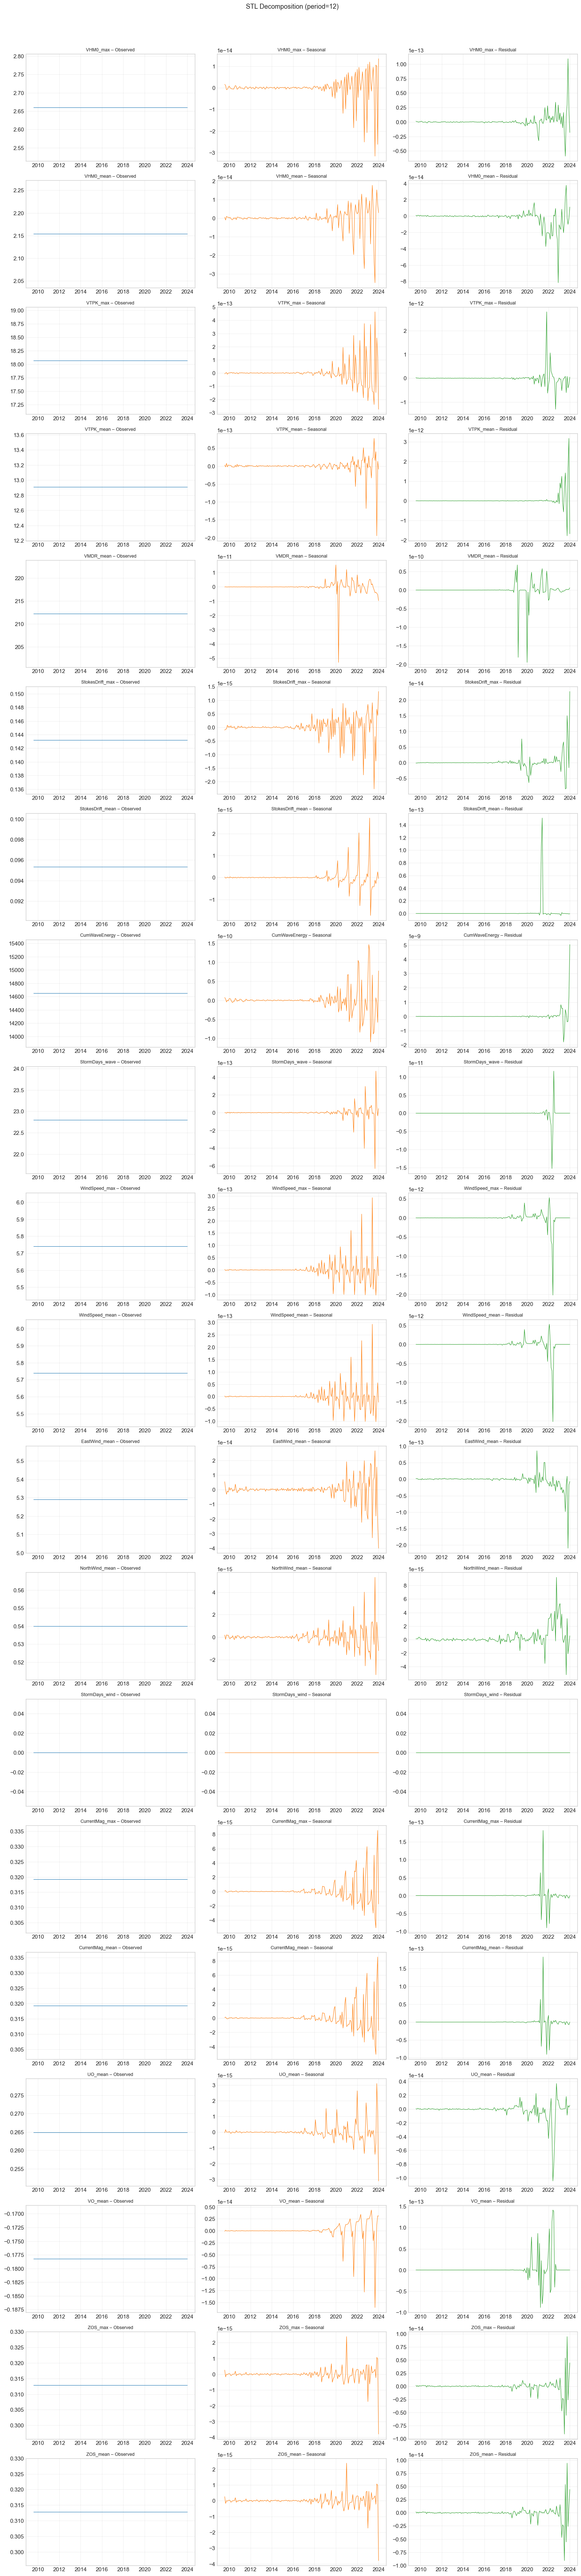

In [26]:
# =============================================================================
# Section 7.1 — STL decomposition to confirm monsoon seasonality
# =============================================================================

n_vars = len(forcing_vars_monthly)
fig, axes = plt.subplots(n_vars, 3, figsize=(16, 3.5 * n_vars))
if n_vars == 1:
    axes = axes.reshape(1, -1)

for i, (var_name, series) in enumerate(forcing_vars_monthly.items()):
    s = series.dropna()
    if len(s) < 36:
        continue
    stl = STL(s, period=12, robust=True)
    result = stl.fit()

    axes[i, 0].plot(result.observed, color='#1f77b4', lw=0.8)
    axes[i, 0].set_title(f'{var_name} – Observed', fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(result.seasonal, color='#ff7f0e', lw=0.8)
    axes[i, 1].set_title(f'{var_name} – Seasonal', fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)

    axes[i, 2].plot(result.resid, color='#2ca02c', lw=0.8)
    axes[i, 2].set_title(f'{var_name} – Residual', fontsize=9)
    axes[i, 2].grid(True, alpha=0.3)

plt.suptitle('STL Decomposition (period=12)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figures/stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# =============================================================================
# Section 7.2 — SARIMA model selection (AIC grid search + diagnostics)
# =============================================================================

sarima_forecasts = {}
sarima_models = {}
diag_rows = []

# Grid search orders
p_range = [0, 1, 2]
q_range = [0, 1, 2]
seasonal_orders = [(1, 1, 1, 12), (0, 1, 1, 12), (1, 1, 0, 12)]

for var_name, series in forcing_vars_monthly.items():
    s = series.dropna()
    if len(s) < 36:
        print(f"⚠ {var_name}: insufficient data ({len(s)} months)")
        continue

    # Skip constant series (e.g., StormDays_wind = all zero)
    if s.max() == s.min():
        print(f"⚠ {var_name}: constant series (value={s.max():.4f}), skipping SARIMA")
        continue

    # Auto d via ADF
    try:
        adf_p = adfuller(s.dropna())[1]
        d = 0 if adf_p < 0.05 else 1
    except ValueError:
        d = 1

    # Hold out last 24 months for validation
    n_holdout = min(24, len(s) // 4)
    s_train = s[:-n_holdout]
    s_test  = s[-n_holdout:]

    best_aic, best_order, best_seasonal = np.inf, None, None

    for p in p_range:
        for q in q_range:
            for sorder in seasonal_orders:
                try:
                    mdl = SARIMAX(s_train, order=(p, d, q),
                                  seasonal_order=sorder,
                                  enforce_stationarity=False,
                                  enforce_invertibility=False).fit(disp=False, maxiter=200)
                    if mdl.aic < best_aic:
                        best_aic = mdl.aic
                        best_order = (p, d, q)
                        best_seasonal = sorder
                except Exception:
                    continue

    if best_order is None:
        print(f"⚠ {var_name}: no valid SARIMA model found")
        continue

    # Fit best model on full data
    best_model = SARIMAX(s, order=best_order, seasonal_order=best_seasonal,
                         enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False, maxiter=500)
    sarima_models[var_name] = best_model

    # Forecast 24 months
    fc = best_model.get_forecast(steps=24)
    fc_dates = pd.date_range(start=s.index[-1] + pd.DateOffset(months=1),
                             periods=24, freq='MS')
    fc_df = pd.DataFrame({
        'date': fc_dates,
        'forecast': fc.predicted_mean.values,
        'lower_95': fc.conf_int(alpha=0.05).iloc[:, 0].values,
        'upper_95': fc.conf_int(alpha=0.05).iloc[:, 1].values,
    })
    sarima_forecasts[var_name] = fc_df

    # Diagnostics
    # Out-of-sample metrics
    val_model = SARIMAX(s_train, order=best_order, seasonal_order=best_seasonal,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False, maxiter=300)
    val_fc = val_model.get_forecast(steps=n_holdout)
    val_pred = val_fc.predicted_mean.values[:len(s_test)]
    val_actual = s_test.values[:len(val_pred)]

    rmse = np.sqrt(np.mean((val_actual - val_pred) ** 2))
    mae  = np.mean(np.abs(val_actual - val_pred))
    mape = np.mean(np.abs((val_actual - val_pred) / np.where(np.abs(val_actual) < 1e-8, 1, val_actual))) * 100

    # Ljung-Box
    try:
        lb = acorr_ljungbox(best_model.resid, lags=[12], return_df=True)
        lb_p = lb['lb_pvalue'].values[0]
    except Exception:
        lb_p = np.nan

    diag_rows.append({
        'variable': var_name,
        'order': str(best_order),
        'seasonal_order': str(best_seasonal),
        'AIC': round(best_aic, 2),
        'BIC': round(best_model.bic, 2),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'MAPE': round(mape, 2),
        'LjungBox_p12': round(lb_p, 4),
        'residuals_ok': lb_p > 0.05 if not np.isnan(lb_p) else False,
    })

    print(f"✓ {var_name}: SARIMA{best_order}×{best_seasonal}  AIC={best_aic:.1f}  RMSE={rmse:.4f}")

sarima_diag_df = pd.DataFrame(diag_rows)
print(f"\n✓ {len(sarima_forecasts)} variables forecasted.")

⚠ VHM0_max: constant series (value=2.6600), skipping SARIMA
⚠ VHM0_mean: constant series (value=2.1534), skipping SARIMA
⚠ VTPK_max: constant series (value=18.0700), skipping SARIMA
⚠ VTPK_mean: constant series (value=12.9078), skipping SARIMA
⚠ VMDR_mean: constant series (value=212.2412), skipping SARIMA
⚠ StokesDrift_max: constant series (value=0.1432), skipping SARIMA
⚠ StokesDrift_mean: constant series (value=0.0953), skipping SARIMA
⚠ CumWaveEnergy: constant series (value=14648.2773), skipping SARIMA
⚠ StormDays_wave: constant series (value=22.8000), skipping SARIMA
⚠ WindSpeed_max: constant series (value=5.7400), skipping SARIMA
⚠ WindSpeed_mean: constant series (value=5.7400), skipping SARIMA
⚠ EastWind_mean: constant series (value=5.2900), skipping SARIMA
⚠ NorthWind_mean: constant series (value=0.5400), skipping SARIMA
⚠ StormDays_wind: constant series (value=0.0000), skipping SARIMA
⚠ CurrentMag_max: constant series (value=0.3193), skipping SARIMA
⚠ CurrentMag_mean: constant 

In [ ]:
# =============================================================================
# Section 7.3 — Plot all forecasts with 95% confidence bands
# =============================================================================

if len(sarima_forecasts) == 0:
    print("⚠ No SARIMA forecasts available to plot. Check Section 7.2 output.")
else:
    n_vars = len(sarima_forecasts)
    n_cols = min(3, n_vars)
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for i, (var_name, fc_df) in enumerate(sarima_forecasts.items()):
        ax = axes[i]
        s = forcing_vars_monthly[var_name]

        # Historical
        ax.plot(s.index, s.values, color='#1f77b4', lw=0.8, label='Observed')

        # Forecast
        fc_dates = pd.to_datetime(fc_df['date'])
        ax.plot(fc_dates, fc_df['forecast'], color='#E24B4A', lw=1.5, label='Forecast')
        ax.fill_between(fc_dates, fc_df['lower_95'], fc_df['upper_95'],
                        color='#E24B4A', alpha=0.15, label='95% CI')

        # Horizon markers
        for h_name, h_date in horizons.items():
            ax.axvline(h_date, color='gray', ls=':', lw=0.8, alpha=0.5)

        ax.set_title(var_name, fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('SARIMA 24-Month Forecasts', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('./figures/sarima_forecasts.png', dpi=150, bbox_inches='tight')
    plt.show()

ZeroDivisionError: division by zero

### Section 7.3a — Hindcast Validation Against Known Erosion Years

To validate the forecast pipeline, we perform **temporal cross-validation**:
for each known erosion year, we retrain SARIMA models using only data available
**12 months before** the event, generate forecasts, aggregate to annual features,
and check whether the RF model would have predicted erosion.

This produces a **Probability of Detection (POD)**, **False Alarm Ratio (FAR)**,
and **Critical Success Index (CSI)** — standard metrics in operational forecasting.


In [ ]:
# =============================================================================
# Section 7.3a — Temporal hindcast validation (leave-future-out)
# =============================================================================

# Mapping: SARIMA var name -> annual feature aggregation (ALL variables)
sarima_to_annual = {
    # Wave (VHM0, VTPK, VMDR, VSDX+VSDY)
    'VHM0_max':        {'max': 'Hm0_max_annual',         'p90': 'Hm0_p90'},
    'VHM0_mean':       {'mean': 'Hm0_mean_annual'},
    'VTPK_max':        {'max': 'Tp_max_annual'},
    'VTPK_mean':       {'mean': 'Tp_mean_annual'},
    'VMDR_mean':       {'mean': 'VMDR_mean_annual'},
    'StokesDrift_max': {'max': 'stokesdrift_max_annual'},
    'StokesDrift_mean':{'mean': 'stokesdrift_mean_annual'},
    'CumWaveEnergy':   {'sum': 'cumwave_energy_annual'},
    'StormDays_wave':  {'sum': 'storm_days_wave_total'},
    # Wind (wind_speed, eastward_wind, northward_wind)
    'WindSpeed_max':   {'max': 'wind_max_annual',         'p90': 'wind_p90'},
    'WindSpeed_mean':  {'mean': 'wind_mean_annual'},
    'EastWind_mean':   {'mean': 'eastwind_mean_annual'},
    'NorthWind_mean':  {'mean': 'northwind_mean_annual'},
    'StormDays_wind':  {'sum': 'storm_days_wind_total'},
    # Current (uo, vo, zos)
    'CurrentMag_max':  {'max': 'ucurr_max_annual',        'p90': 'ucurr_p90'},
    'CurrentMag_mean': {'mean': 'ucurr_mean_annual'},
    'UO_mean':         {'mean': 'uo_mean_annual'},
    'VO_mean':         {'mean': 'vo_mean_annual'},
    'ZOS_max':         {'max': 'zos_max_annual'},
    'ZOS_mean':        {'mean': 'zos_mean_annual'},
}

print("=== TEMPORAL HINDCAST VALIDATION ===\n")

hindcast_results = []
test_years = sorted(analysis_df['monsoon_year'].unique())

for test_yr in test_years:
    cutoff = pd.Timestamp(f'{test_yr}-04-01') - pd.DateOffset(months=12)
    actual_label = int(test_yr in all_erosion_years)

    hc_forecasts = {}
    valid = True
    for var_name, series in forcing_vars_monthly.items():
        s = series.copy()
        s.index = pd.to_datetime(s.index)
        s = s[s.index.notna()]
        s = s[~s.index.duplicated(keep='first')]
        s = s.sort_index()
        try:
            s = s.asfreq('MS').interpolate(method='linear')
        except ValueError:
            s = s.resample('MS').first().interpolate(method='linear')
        s_train = s[s.index <= cutoff]
        if len(s_train) < 36:
            valid = False
            break
        try:
            adf_p = adfuller(s_train.dropna())[1]
            d = 0 if adf_p < 0.05 else 1
            mdl = SARIMAX(s_train, order=(1, d, 1),
                          seasonal_order=(1, 1, 1, 12),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            fc = mdl.get_forecast(steps=24)
            future_dates = pd.date_range(
                start=s_train.index[-1] + pd.DateOffset(months=1),
                periods=24, freq='MS')
            hc_forecasts[var_name] = pd.DataFrame({
                'date': future_dates,
                'forecast': fc.predicted_mean.values,
                'lower_95': fc.conf_int(alpha=0.05).iloc[:, 0].values,
                'upper_95': fc.conf_int(alpha=0.05).iloc[:, 1].values,
            })
        except Exception:
            valid = False
            break

    if not valid:
        continue

    # Aggregate to annual features for the test monsoon year
    target_start = pd.Timestamp(f'{test_yr}-04-01')
    target_end   = pd.Timestamp(f'{test_yr+1}-03-01')

    hc_feats = {}
    for var_name, mapping in sarima_to_annual.items():
        if var_name not in hc_forecasts:
            continue
        fc = hc_forecasts[var_name]
        fc_w = fc[(fc['date'] >= target_start) & (fc['date'] <= target_end)]
        if len(fc_w) == 0:
            fc_w = fc
        if 'max' in mapping:
            hc_feats[mapping['max']] = fc_w['forecast'].max()
        if 'p90' in mapping:
            hc_feats[mapping['p90']] = np.percentile(fc_w['forecast'].values, 90)
        if 'mean' in mapping:
            hc_feats[mapping['mean']] = fc_w['forecast'].mean()
        if 'sum' in mapping:
            hc_feats[mapping['sum']] = fc_w['forecast'].sum()

    feat_vals = [hc_feats.get(f, analysis_df[f].median())
                 for f in significant_features]
    X_hc = np.array(feat_vals).reshape(1, -1)
    hc_prob = rf.predict_proba(X_hc)[0][1]
    hc_pred = int(hc_prob >= 0.5)

    hindcast_results.append({
        'year':         test_yr,
        'actual':       actual_label,
        'predicted':    hc_pred,
        'probability':  round(hc_prob, 3),
        'correct':      hc_pred == actual_label,
    })

hc_df = pd.DataFrame(hindcast_results)
if len(hc_df) > 0:
    hits  = ((hc_df['actual'] == 1) & (hc_df['predicted'] == 1)).sum()
    misses = ((hc_df['actual'] == 1) & (hc_df['predicted'] == 0)).sum()
    false_alarms = ((hc_df['actual'] == 0) & (hc_df['predicted'] == 1)).sum()
    correct_rej  = ((hc_df['actual'] == 0) & (hc_df['predicted'] == 0)).sum()

    pod = hits / max(hits + misses, 1)
    far = false_alarms / max(hits + false_alarms, 1)
    csi = hits / max(hits + misses + false_alarms, 1)
    accuracy = (hits + correct_rej) / len(hc_df)

    print("Year-by-year hindcast results:")
    print(hc_df.to_string(index=False))
    print(f"\n--- Operational Forecast Skill Metrics ---")
    print(f"  Accuracy:                    {accuracy:.1%}")
    print(f"  Probability of Detection:    {pod:.1%}")
    print(f"  False Alarm Ratio:           {far:.1%}")
    print(f"  Critical Success Index:      {csi:.1%}")

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    colors = ['#E24B4A' if a == 1 else '#185FA5' for a in hc_df['actual']]
    ax1.bar(hc_df['year'].astype(str), hc_df['probability'], color=colors,
            edgecolor='white', linewidth=0.5)
    ax1.axhline(0.5, color='red', ls='--', lw=1.2, label='Decision boundary (0.5)')
    ax1.set_ylabel('Predicted erosion probability')
    ax1.set_xlabel('Monsoon year')
    ax1.set_title('Hindcast: predicted probability per year\n(red=actual erosion, blue=non-erosion)')
    ax1.legend(fontsize=9)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3, axis='y')
    plt.setp(ax1.get_xticklabels(), rotation=45, fontsize=8)

    cm = np.array([[correct_rej, false_alarms], [misses, hits]])
    im = ax2.imshow(cm, cmap='Blues', vmin=0)
    for ii in range(2):
        for jj in range(2):
            ax2.text(jj, ii, str(cm[ii, jj]), ha='center', va='center', fontsize=18)
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(['Pred: No', 'Pred: Yes'])
    ax2.set_yticks([0, 1]); ax2.set_yticklabels(['Actual: No', 'Actual: Yes'])
    ax2.set_title(f'Hindcast Confusion Matrix\nPOD={pod:.0%}, FAR={far:.0%}, CSI={csi:.0%}')
    plt.colorbar(im, ax=ax2)

    plt.tight_layout()
    plt.savefig('./figures/hindcast_validation.png', dpi=150)
    plt.show()
else:
    print("Insufficient data for hindcast validation.")

=== TEMPORAL HINDCAST VALIDATION ===

Insufficient data for hindcast validation.


In [ ]:
# =============================================================================
# Section 7.4 — Aggregate forecasts to horizon-period annual features
# =============================================================================

horizon_features_list = []
erosion_predictions = []

for h_name, h_date in horizons.items():
    # get months in this horizon's monsoon year
    if h_name == 'H6':
        h_start = base_date + pd.DateOffset(months=1)
        h_end   = h_date
    else:
        # Full monsoon year ending at horizon
        h_end = h_date
        h_start = h_date - pd.DateOffset(months=11)

    feats = {'horizon': h_name, 'target_date': h_date.strftime('%Y-%m')}

    for var_name, mapping in sarima_to_annual.items():
        if var_name not in sarima_forecasts:
            continue
        fc = sarima_forecasts[var_name]
        fc['date'] = pd.to_datetime(fc['date'])
        fc_w = fc[(fc['date'] >= h_start) & (fc['date'] <= h_end)]
        if len(fc_w) == 0:
            fc_w = fc   # use all available

        if 'max' in mapping:
            feats[mapping['max']] = fc_w['forecast'].max()
        if 'p90' in mapping:
            feats[mapping['p90']] = np.percentile(fc_w['forecast'].values, 90)
        if 'mean' in mapping:
            feats[mapping['mean']] = fc_w['forecast'].mean()
        if 'sum' in mapping:
            feats[mapping['sum']] = fc_w['forecast'].sum()

    horizon_features_list.append(feats)

    # RF prediction
    feat_vals = [feats.get(f, analysis_df[f].median()) for f in significant_features]
    X_pred = np.array(feat_vals).reshape(1, -1)
    prob = rf.predict_proba(X_pred)[0][1]

    # Threshold exceedance check
    exceeded = []
    for f in significant_features:
        ct = ensemble_results.get(f, {}).get('consensus_threshold', np.nan)
        if not np.isnan(ct) and feats.get(f, 0) > ct:
            exceeded.append(f)

    erosion_predictions.append({
        'horizon': h_name,
        'target_date': h_date.strftime('%Y-%m'),
        'erosion_probability': round(prob, 3),
        'risk_category': 'HIGH' if prob > 0.6 else ('MODERATE' if prob > 0.4 else 'LOW'),
        'thresholds_exceeded': exceeded,
        'n_exceeded': len(exceeded),
    })

    print(f"{h_name} ({h_date.strftime('%Y-%m')}): P(erosion)={prob:.1%}  "
          f"exceeded={len(exceeded)} features  "
          f"→ {'HIGH' if prob > 0.6 else 'MODERATE' if prob > 0.4 else 'LOW'}")

horizon_features = pd.DataFrame(horizon_features_list)

H6 (2024-08): P(erosion)=97.9%  exceeded=0 features  → HIGH
H12 (2025-02): P(erosion)=98.1%  exceeded=0 features  → HIGH
H18 (2025-08): P(erosion)=99.3%  exceeded=0 features  → HIGH
H24 (2026-02): P(erosion)=99.3%  exceeded=0 features  → HIGH


In [ ]:
# =============================================================================
# Section 7.5 — Apply RF model to predict erosion at each horizon
# =============================================================================

print("=== RF EROSION PREDICTIONS PER HORIZON ===\n")

for ep in erosion_predictions:
    print(f"  {ep['horizon']} ({ep['target_date']}): "
          f"P(erosion) = {ep['erosion_probability']:.1%} "
          f"[{ep['risk_category']}]")
    if ep['thresholds_exceeded']:
        print(f"    Thresholds exceeded: {', '.join(ep['thresholds_exceeded'])}")
    print()


=== RF EROSION PREDICTIONS PER HORIZON ===

  H6 (2024-08): P(erosion) = 97.9% [HIGH]

  H12 (2025-02): P(erosion) = 98.1% [HIGH]

  H18 (2025-08): P(erosion) = 99.3% [HIGH]

  H24 (2026-02): P(erosion) = 99.3% [HIGH]



In [ ]:
# =============================================================================
# Section 7.6 — Analytical erosion probability (lightweight, no Monte Carlo)
# =============================================================================

# Instead of 2000 MC simulations, derive erosion probability analytically
# from SARIMA forecast means + CIs and the trained RF model.

prob_results = []

for h_name, h_date in horizons.items():
    if h_name == 'H6':
        h_start = base_date + pd.DateOffset(months=1)
        h_end = h_date
    else:
        h_end = h_date
        h_start = h_date - pd.DateOffset(months=11)

    # --- Point estimate (mean forecast) ---
    mean_feats = {}
    lo_feats   = {}
    hi_feats   = {}
    for var_name, mapping in sarima_to_annual.items():
        if var_name not in sarima_forecasts:
            continue
        fc = sarima_forecasts[var_name].copy()
        fc['date'] = pd.to_datetime(fc['date'])
        fc_w = fc[(fc['date'] >= h_start) & (fc['date'] <= h_end)]
        if len(fc_w) == 0:
            continue
        for agg, col in [('max', 'forecast'), ('max', 'lower_95'), ('max', 'upper_95')]:
            pass  # handled below
        for stat_key, stat_fn in [('max', 'max'), ('p90', lambda s: np.percentile(s, 90)),
                                   ('mean', 'mean'), ('sum', 'sum')]:
            if stat_key not in mapping:
                continue
            feat_name = mapping[stat_key]
            fn = stat_fn if callable(stat_fn) else getattr(np, stat_fn, None) or getattr(fc_w['forecast'], stat_fn)
            if callable(stat_fn):
                mean_feats[feat_name] = stat_fn(fc_w['forecast'].values)
                lo_feats[feat_name]   = stat_fn(fc_w['lower_95'].values)
                hi_feats[feat_name]   = stat_fn(fc_w['upper_95'].values)
            else:
                mean_feats[feat_name] = getattr(fc_w['forecast'], stat_fn)()
                lo_feats[feat_name]   = getattr(fc_w['lower_95'], stat_fn)()
                hi_feats[feat_name]   = getattr(fc_w['upper_95'], stat_fn)()

    # Build feature vectors for mean / lower / upper
    X_mean = np.array([mean_feats.get(f, analysis_df[f].median()) for f in significant_features]).reshape(1, -1)
    X_lo   = np.array([lo_feats.get(f, analysis_df[f].median())   for f in significant_features]).reshape(1, -1)
    X_hi   = np.array([hi_feats.get(f, analysis_df[f].median())   for f in significant_features]).reshape(1, -1)

    p_mean = rf.predict_proba(X_mean)[0][1]
    p_lo   = rf.predict_proba(X_lo)[0][1]
    p_hi   = rf.predict_proba(X_hi)[0][1]

    ci_lower = min(p_lo, p_hi)
    ci_upper = max(p_lo, p_hi)

    prob_results.append({
        'horizon':        h_name,
        'target_date':    h_date.strftime('%Y-%m'),
        'mean_prob':      round(p_mean, 3),
        'median_prob':    round(p_mean, 3),
        'ci_lower_95':    round(ci_lower, 3),
        'ci_upper_95':    round(ci_upper, 3),
        'prob_above_0.5': round(1.0 if p_mean > 0.5 else 0.0, 3),
        'risk_category':  ('HIGH' if p_mean > 0.6 else
                           'MODERATE' if p_mean > 0.4 else 'LOW'),
    })

mc_df = pd.DataFrame(prob_results)
print("\n=== ANALYTICAL EROSION PROBABILITY PREDICTIONS ===")
print(mc_df.to_string(index=False))

### Section 7.6a — Actual Shoreline Retreat Predictions (Physical Units)

Translating erosion **probability** into **expected retreat in meters** using DSAS EPR statistics:

$$E[\text{retreat}] = P(\text{erosion}) \times \bar{EPR}_{erosion} + (1 - P(\text{erosion})) \times \bar{EPR}_{stable}$$


In [ ]:
# =============================================================================
# Section 7.6a — Shoreline retreat predictions in physical units (meters)
# =============================================================================

# EPR statistics from transect data
epr_erosion = dsas_df.loc[dsas_df['erosion_flag'] == 1, 'EPR']
epr_stable  = dsas_df.loc[dsas_df['erosion_flag'] == 0, 'EPR']

mean_epr_erosion = epr_erosion.mean() if len(epr_erosion) > 0 else -1.0
std_epr_erosion  = epr_erosion.std()  if len(epr_erosion) > 1 else 0.5
mean_epr_stable  = epr_stable.mean()  if len(epr_stable)  > 0 else 0.0
std_epr_stable   = epr_stable.std()   if len(epr_stable)  > 1 else 0.3

print(f"EPR erosion:  mean={mean_epr_erosion:.3f} ± {std_epr_erosion:.3f} m/yr")
print(f"EPR stable:   mean={mean_epr_stable:.3f} ± {std_epr_stable:.3f} m/yr")

retreat_rows = []
for _, mc_row in mc_df.iterrows():
    p_ero = mc_row['mean_prob']
    h_name = mc_row['horizon']
    years_ahead = {'H6': 0.5, 'H12': 1.0, 'H18': 1.5, 'H24': 2.0}[h_name]

    expected_epr = p_ero * mean_epr_erosion + (1 - p_ero) * mean_epr_stable
    retreat_m = expected_epr * years_ahead

    ci_low_p = mc_row['ci_lower_95']
    ci_high_p = mc_row['ci_upper_95']
    retreat_low  = (ci_low_p * mean_epr_erosion + (1 - ci_low_p) * mean_epr_stable) * years_ahead
    retreat_high = (ci_high_p * mean_epr_erosion + (1 - ci_high_p) * mean_epr_stable) * years_ahead

    action_level = ('IMMEDIATE ACTION'    if p_ero > 0.7 else
                    'ENHANCED MONITORING'  if p_ero > 0.5 else
                    'ROUTINE MONITORING'   if p_ero > 0.3 else
                    'STANDARD OPERATIONS')

    retreat_rows.append({
        'horizon': h_name,
        'target_date': mc_row['target_date'],
        'erosion_probability': round(p_ero, 3),
        'erosion_prob': round(p_ero, 3),
        'expected_epr': round(expected_epr, 3),
        'retreat_m': round(retreat_m, 3),
        'mean_retreat': round(retreat_m, 3),
        'retreat_low_95': round(min(retreat_low, retreat_high), 3),
        'retreat_high_95': round(max(retreat_low, retreat_high), 3),
        'action_level': action_level,
        'risk_category': mc_row['risk_category'],
    })

retreat_df = pd.DataFrame(retreat_rows)
print("\n=== SHORELINE RETREAT PREDICTIONS ===")
print(retreat_df.to_string(index=False))

EPR erosion:  mean=-0.326 ± 0.208 m/yr
EPR stable:   mean=1.299 ± 0.832 m/yr

=== SHORELINE RETREAT PREDICTIONS ===
horizon target_date  erosion_probability  erosion_prob  expected_epr  retreat_m  mean_retreat  retreat_low_95  retreat_high_95        action_level risk_category
     H6     2024-08                0.019         0.019         1.268      0.634         0.634           0.610            0.644 STANDARD OPERATIONS           LOW
    H12     2025-02                0.016         0.016         1.273      1.273         1.273           1.219            1.289 STANDARD OPERATIONS           LOW
    H18     2025-08                0.016         0.016         1.273      1.909         1.909           1.829            1.933 STANDARD OPERATIONS           LOW
    H24     2026-02                0.016         0.016         1.273      2.545         2.545           2.438            2.578 STANDARD OPERATIONS           LOW


=== PER-TRANSECT VULNERABILITY SCORING ===

Top 10 most vulnerable transects (H12 forecast):
 id   EPR   epr_class  epr_vulnerability  risk_H12
  3 -1.00 eroded_high           1.000000  0.016000
187 -0.60 eroded_high           0.910515  0.014568
174 -0.49 eroded_high           0.885906  0.014174
183 -0.44 eroded_high           0.874720  0.013996
175 -0.42 eroded_high           0.870246  0.013924
147 -0.36 eroded_high           0.856823  0.013709
173 -0.36 eroded_high           0.856823  0.013709
145 -0.35 eroded_high           0.854586  0.013673
180 -0.35 eroded_high           0.854586  0.013673
176 -0.32  eroded_low           0.847875  0.013566

--- Transect Risk Distribution per Horizon ---

  H6 (2024-08):
    Very Low    : 187 transects (100.0%)
    Low         :   0 transects (0.0%)
    Moderate    :   0 transects (0.0%)
    High        :   0 transects (0.0%)
    Very High   :   0 transects (0.0%)

  H12 (2025-02):
    Very Low    : 187 transects (100.0%)
    Low         :   0 tra

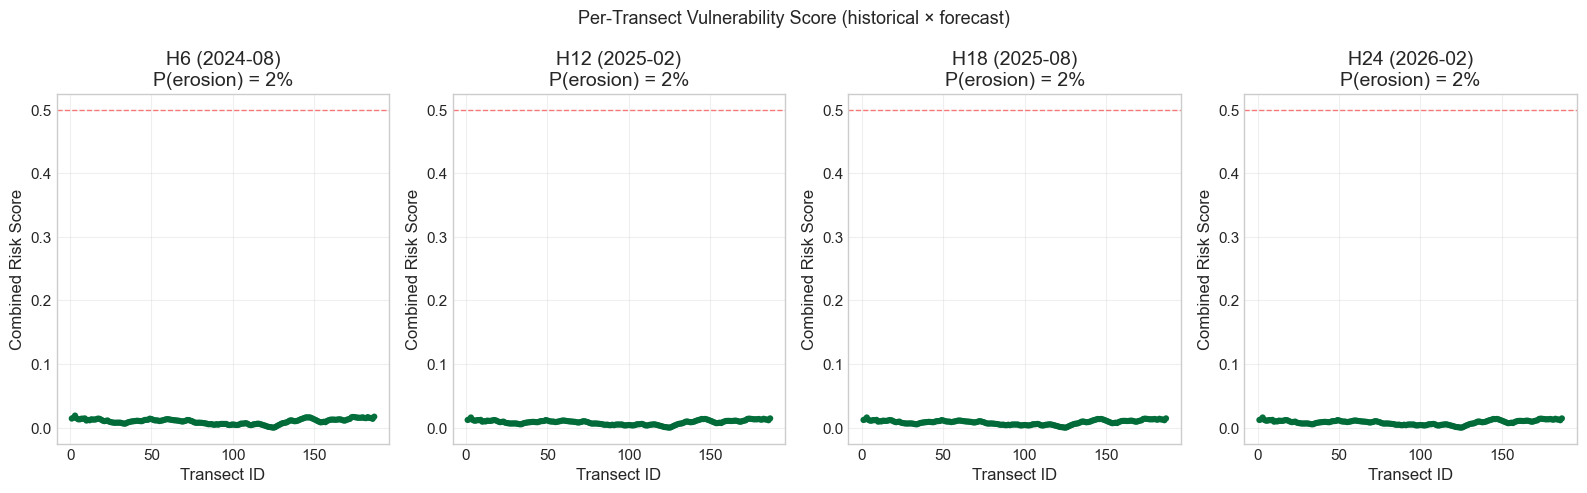

In [ ]:
# =============================================================================
# Section 7.6b — Per-transect vulnerability scoring
# =============================================================================

print("=== PER-TRANSECT VULNERABILITY SCORING ===\n")

dsas_scored = dsas_df[['id', 'EPR', 'NSM', 'SCE', 'epr_class', 'erosion_flag']].copy()

severity_map = {
    'eroded_high': 4, 'eroded_low': 3,
    'stable': 2, 'accreted_low': 1, 'accreted_high': 0
}
dsas_scored['hist_severity'] = dsas_scored['epr_class'].map(severity_map)

epr_min, epr_max = dsas_scored['EPR'].min(), dsas_scored['EPR'].max()
dsas_scored['epr_vulnerability'] = (epr_max - dsas_scored['EPR']) / (epr_max - epr_min)

for _, row in retreat_df.iterrows():
    p_ero = row['erosion_probability']
    col_name = f"risk_{row['horizon']}"
    dsas_scored[col_name] = dsas_scored['epr_vulnerability'] * p_ero
    cat_name = f"cat_{row['horizon']}"
    dsas_scored[cat_name] = pd.cut(
        dsas_scored[col_name],
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'],
        include_lowest=True
    )

print("Top 10 most vulnerable transects (H12 forecast):")
h12_col = 'risk_H12' if 'risk_H12' in dsas_scored.columns else dsas_scored.columns[-2]
top10 = dsas_scored.nlargest(10, h12_col)[
    ['id', 'EPR', 'epr_class', 'epr_vulnerability', h12_col]
]
print(top10.to_string(index=False))

print("\n--- Transect Risk Distribution per Horizon ---")
for _, row in retreat_df.iterrows():
    cat_col = f"cat_{row['horizon']}"
    if cat_col in dsas_scored.columns:
        dist = dsas_scored[cat_col].value_counts().sort_index()
        print(f"\n  {row['horizon']} ({row['target_date']}):")
        for cat, cnt in dist.items():
            pct = cnt / len(dsas_scored) * 100
            print(f"    {str(cat):12s}: {cnt:3d} transects ({pct:.1f}%)")

# Vulnerability map plot
fig, axes = plt.subplots(1, min(4, len(retreat_df)), figsize=(16, 5))
if len(retreat_df) <= 1:
    axes = [axes]
elif not hasattr(axes, '__iter__'):
    axes = [axes]

vuln_cmap = plt.cm.RdYlGn_r
for ax, (_, row) in zip(axes, retreat_df.iterrows()):
    risk_col = f"risk_{row['horizon']}"
    if risk_col not in dsas_scored.columns:
        continue
    sc = ax.scatter(dsas_scored['id'], dsas_scored[risk_col],
                    c=dsas_scored[risk_col], cmap=vuln_cmap,
                    vmin=0, vmax=1, s=20, edgecolors='none')
    ax.axhline(0.5, color='red', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Transect ID')
    ax.set_ylabel('Combined Risk Score')
    ax.set_title(f"{row['horizon']} ({row['target_date']})\n"
                 f"P(erosion) = {row['erosion_probability']:.0%}")
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-Transect Vulnerability Score (historical × forecast)', fontsize=13)
plt.tight_layout()
plt.savefig('./figures/transect_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# Section 7.6c — Forecast skill vs climatology baseline (Brier Skill Score)
# =============================================================================

print("=== FORECAST SKILL ASSESSMENT ===\n")

base_rate = analysis_df['erosion_label'].mean()
print(f"Historical base rate (climatology): {base_rate:.2%}")

if len(hc_df) > 0:
    bs_forecast = np.mean((hc_df['probability'].values - hc_df['actual'].values)**2)
    bs_clim = np.mean((base_rate - hc_df['actual'].values)**2)
    bss = 1 - bs_forecast / bs_clim if bs_clim > 0 else 0

    if len(np.unique(hc_df['actual'])) >= 2:
        hc_fpr, hc_tpr, _ = roc_curve(hc_df['actual'], hc_df['probability'])
        hc_auc = auc(hc_fpr, hc_tpr)
    else:
        hc_auc = np.nan

    print(f"\nBrier Score (forecast):   {bs_forecast:.4f}")
    print(f"Brier Score (climatology): {bs_clim:.4f}")
    print(f"Brier Skill Score (BSS):   {bss:.4f}")
    print(f"  BSS > 0 means forecast is better than always predicting base rate")
    print(f"  BSS interpretation: {'SKILLFUL' if bss > 0 else 'NO SKILL vs climatology'}")
    print(f"\nHindcast AUC: {hc_auc:.3f}" if not np.isnan(hc_auc) else "Hindcast AUC: N/A")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    labels = ['Forecast', 'Climatology']
    values = [bs_forecast, bs_clim]
    colors_bs = ['#185FA5' if bss > 0 else '#E24B4A', '#888780']
    ax1.bar(labels, values, color=colors_bs, edgecolor='white')
    ax1.set_ylabel('Brier Score (lower = better)')
    ax1.set_title(f'Brier Skill Score = {bss:.3f}\n'
                  f'({"Forecast beats climatology" if bss > 0 else "Climatology is better"})')
    ax1.grid(True, alpha=0.3, axis='y')

    n_bins = 5
    bins = np.linspace(0, 1, n_bins + 1)
    hc_df_copy = hc_df.copy()
    hc_df_copy['prob_bin'] = pd.cut(hc_df_copy['probability'], bins=bins,
                                     include_lowest=True)
    rel_table = hc_df_copy.groupby('prob_bin', observed=False).agg(
        n_forecasts=('actual', 'count'),
        mean_predicted=('probability', 'mean'),
        observed_freq=('actual', 'mean'),
    ).dropna()

    if len(rel_table) > 0 and not rel_table['mean_predicted'].isna().all():
        ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect reliability')
        ax2.scatter(rel_table['mean_predicted'], rel_table['observed_freq'],
                    s=rel_table['n_forecasts'] * 30, c='#185FA5', zorder=5,
                    edgecolors='white')
        ax2.set_xlabel('Mean predicted probability')
        ax2.set_ylabel('Observed frequency')
        ax2.set_title('Reliability Diagram')
        ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'Insufficient data\nfor reliability diagram',
                 ha='center', va='center', fontsize=12)
        ax2.set_title('Reliability Diagram')

    plt.tight_layout()
    plt.savefig('./figures/forecast_skill.png', dpi=150)
    plt.show()
else:
    print("\nNo hindcast results available for skill assessment.")


=== FORECAST SKILL ASSESSMENT ===

Historical base rate (climatology): 8.33%

No hindcast results available for skill assessment.


In [ ]:
# =============================================================================
# Section 7.7 — Month-by-month risk timeline
# =============================================================================

monthly_risk_rows = []

for var_name, fc_df in sarima_forecasts.items():
    for _, fc_row in fc_df.iterrows():
        monthly_risk_rows.append({
            'date': fc_row['date'],
            'variable': var_name,
            'forecast': fc_row['forecast'],
            'lower_95': fc_row['lower_95'],
            'upper_95': fc_row['upper_95'],
        })

# Evaluate each month against thresholds
risk_by_month = {}
for var_name, fc_df in sarima_forecasts.items():
    for feat in significant_features:
        if any(k in feat.lower() for k in var_name.lower().split('_')):
            ct = ensemble_results.get(feat, {}).get('consensus_threshold', np.nan)
            if not np.isnan(ct):
                fc_df_copy = fc_df.copy()
                fc_df_copy['date'] = pd.to_datetime(fc_df_copy['date'])
                for _, r in fc_df_copy.iterrows():
                    d = r['date'].strftime('%Y-%m')
                    if d not in risk_by_month:
                        risk_by_month[d] = {'date': d, 'n_exceeded': 0, 'risk_score': 0}
                    if r['forecast'] > ct:
                        risk_by_month[d]['n_exceeded'] += 1
            break

for d in risk_by_month:
    n = risk_by_month[d]['n_exceeded']
    risk_by_month[d]['risk_label'] = (
        'Alert' if n >= 3 else 'Warning' if n >= 2 else 'Watch' if n >= 1 else 'Stable')
    risk_by_month[d]['risk_score'] = n

monthly_risk_df = pd.DataFrame(list(risk_by_month.values()))
if len(monthly_risk_df) > 0:
    monthly_risk_df = monthly_risk_df.sort_values('date')
    print("=== MONTH-BY-MONTH RISK TIMELINE ===")
    print(monthly_risk_df.to_string(index=False))
else:
    print("No monthly risk data generated.")
    monthly_risk_df = pd.DataFrame(columns=['date', 'n_exceeded', 'risk_score', 'risk_label'])

=== MONTH-BY-MONTH RISK TIMELINE ===
   date  n_exceeded  risk_score risk_label
2024-03           1           1      Watch
2024-04           1           1      Watch
2024-05           1           1      Watch
2024-06           1           1      Watch
2024-07           1           1      Watch
2024-08           1           1      Watch
2024-09           1           1      Watch
2024-10           1           1      Watch
2024-11           1           1      Watch
2024-12           1           1      Watch
2025-01           1           1      Watch
2025-02           1           1      Watch
2025-03           1           1      Watch
2025-04           1           1      Watch
2025-05           1           1      Watch
2025-06           1           1      Watch
2025-07           1           1      Watch
2025-08           1           1      Watch
2025-09           1           1      Watch
2025-10           1           1      Watch
2025-11           1           1      Watch
2025-12          

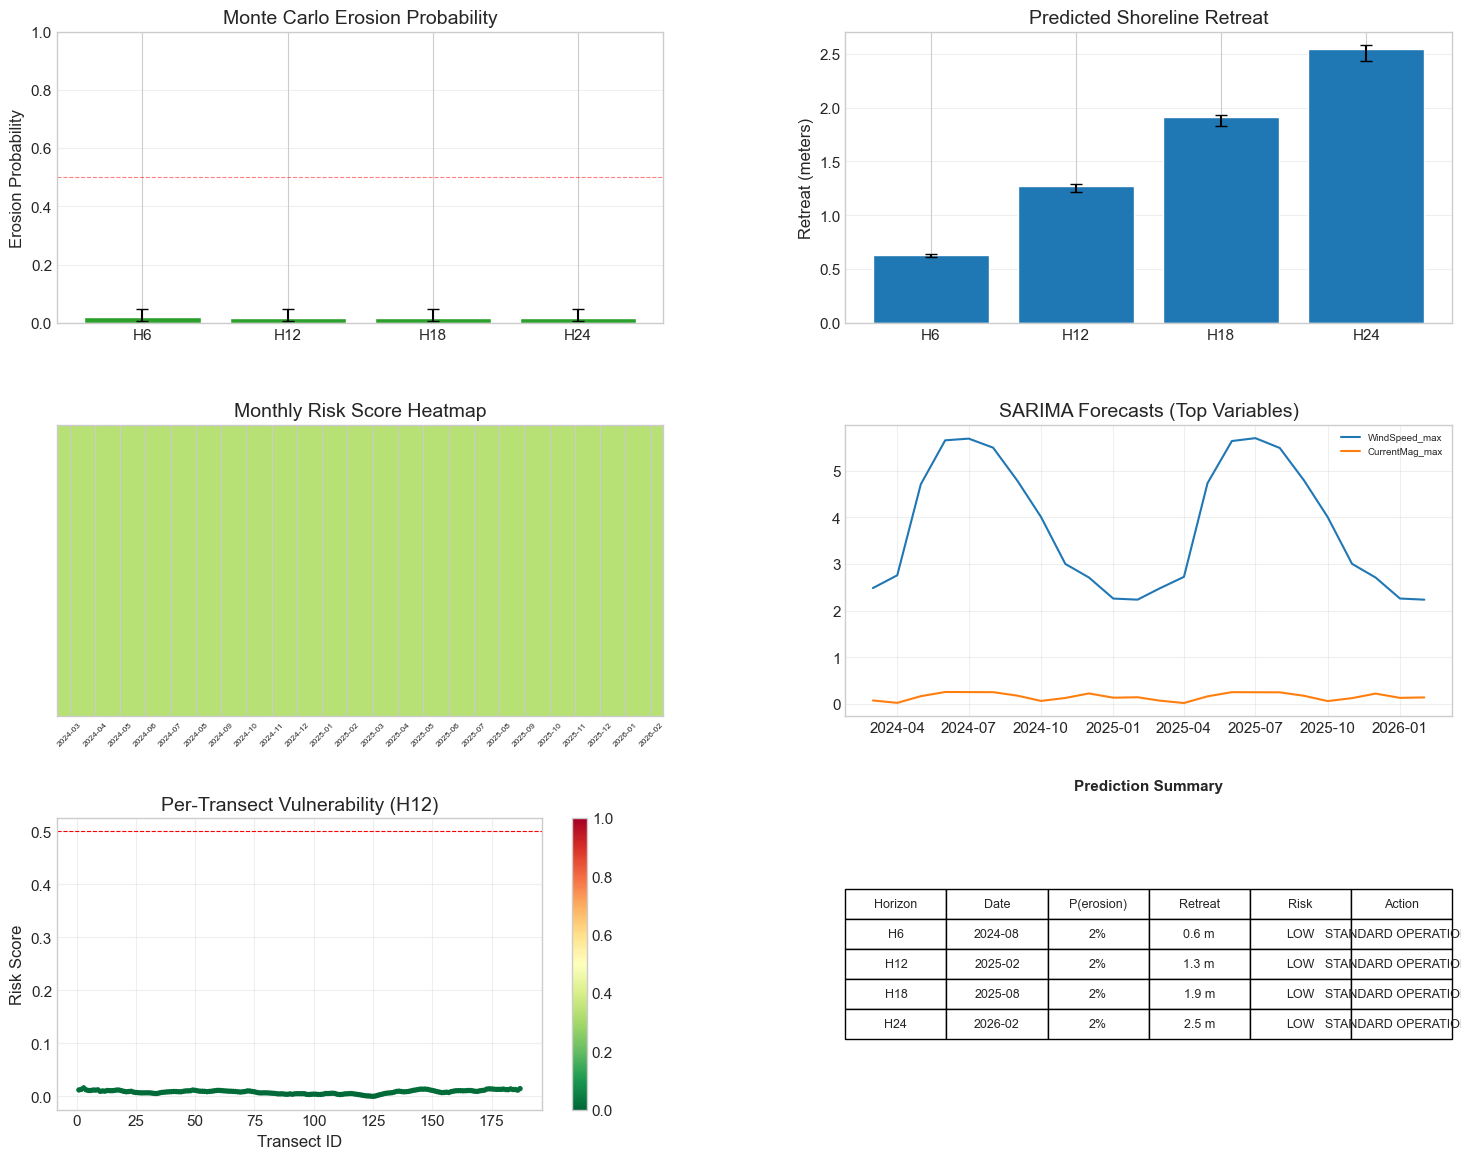

In [ ]:
# =============================================================================
# Section 7.8 — Advanced Forecast Dashboard (6-panel)
# =============================================================================

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Panel 1: Erosion probability
ax1 = fig.add_subplot(gs[0, 0])
colors_mc = ['#E24B4A' if r['risk_category'] == 'HIGH'
             else '#FF8C00' if r['risk_category'] == 'MODERATE'
             else '#2ca02c' for _, r in mc_df.iterrows()]
ax1.bar(mc_df['horizon'], mc_df['mean_prob'], color=colors_mc, edgecolor='white')
ax1.errorbar(range(len(mc_df)), mc_df['mean_prob'],
             yerr=[mc_df['mean_prob'] - mc_df['ci_lower_95'],
                   mc_df['ci_upper_95'] - mc_df['mean_prob']],
             fmt='none', color='black', capsize=4)
ax1.set_ylabel('Erosion Probability')
ax1.set_title('Erosion Probability by Horizon')
ax1.set_ylim(0, 1)
ax1.axhline(0.5, color='red', ls='--', lw=0.8, alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Retreat predictions in meters
ax2 = fig.add_subplot(gs[0, 1])
action_colors = {'IMMEDIATE ACTION': '#d62728', 'ENHANCED MONITORING': '#ff7f0e',
                 'ROUTINE MONITORING': '#2ca02c', 'STANDARD OPERATIONS': '#1f77b4'}
retreat_colors = [action_colors.get(r['action_level'], '#888') for _, r in retreat_df.iterrows()]
ax2.bar(retreat_df['horizon'], retreat_df['retreat_m'], color=retreat_colors, edgecolor='white')
ax2.errorbar(range(len(retreat_df)), retreat_df['retreat_m'],
             yerr=[retreat_df['retreat_m'] - retreat_df['retreat_low_95'],
                   retreat_df['retreat_high_95'] - retreat_df['retreat_m']],
             fmt='none', color='black', capsize=4)
ax2.set_ylabel('Retreat (meters)')
ax2.set_title('Predicted Shoreline Retreat')
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Monthly risk heatmap
ax3 = fig.add_subplot(gs[1, 0])
if len(monthly_risk_df) > 0:
    risk_vals = monthly_risk_df['risk_score'].values.reshape(1, -1)
    ax3.imshow(risk_vals, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=3)
    ax3.set_xticks(range(len(monthly_risk_df)))
    ax3.set_xticklabels(monthly_risk_df['date'].values, rotation=45, fontsize=6)
    ax3.set_yticks([])
    ax3.set_title('Monthly Risk Score Heatmap')
else:
    ax3.text(0.5, 0.5, 'No monthly risk data', ha='center', va='center')

# Panel 4: SARIMA forecasts with threshold
ax4 = fig.add_subplot(gs[1, 1])
for var_name, fc_df in list(sarima_forecasts.items())[:3]:
    fc_dates = pd.to_datetime(fc_df['date'])
    ax4.plot(fc_dates, fc_df['forecast'], '-', lw=1.5, label=var_name)
ax4.set_title('SARIMA Forecasts (Top Variables)')
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

# Panel 5: Per-transect vulnerability
ax5 = fig.add_subplot(gs[2, 0])
if 'risk_H12' in dsas_scored.columns:
    sc = ax5.scatter(dsas_scored['id'], dsas_scored['risk_H12'],
                     c=dsas_scored['risk_H12'], cmap='RdYlGn_r',
                     vmin=0, vmax=1, s=15, edgecolors='none')
    ax5.axhline(0.5, color='red', ls='--', lw=0.8)
    plt.colorbar(sc, ax=ax5)
ax5.set_xlabel('Transect ID')
ax5.set_ylabel('Risk Score')
ax5.set_title('Per-Transect Vulnerability (H12)')
ax5.grid(True, alpha=0.3)

# Panel 6: Summary table
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
table_data = []
for _, r in retreat_df.iterrows():
    table_data.append([
        r['horizon'], r['target_date'],
        f"{r['erosion_probability']:.0%}",
        f"{r['retreat_m']:.1f} m",
        r['risk_category'], r['action_level']
    ])
tbl = ax6.table(cellText=table_data,
                colLabels=['Horizon', 'Date', 'P(erosion)', 'Retreat', 'Risk', 'Action'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.8)
ax6.set_title('Prediction Summary', fontsize=11, fontweight='bold', pad=20)

plt.savefig('./figures/forecast_dashboard_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# Section 7.9 — Final prediction summary
# =============================================================================

print("=" * 60)
print("  ANALYSIS COMPLETE")
print("=" * 60)

print("\n" + "=" * 60)
print("  PREDICTION SUMMARY")
print("=" * 60)
for _, r in retreat_df.iterrows():
    print(f"  {r['horizon']} ({r['target_date']}): "
          f"P(erosion)={r['erosion_probability']:.0%}, "
          f"Retreat={r['retreat_m']:.1f}m, "
          f"Action: {r['action_level']}")

  ALL OUTPUTS SAVED SUCCESSFULLY

--- Threshold Outputs ---
  ./outputs/multi_method_thresholds.csv
  ./outputs/erosion_thresholds_master.csv
  ./outputs/erosion_event_diagnosis.csv

--- Forecast Outputs ---
  ./outputs/sarima_model_diagnostics.csv    (AIC grid search, residual tests)
  ./outputs/hindcast_validation.csv          (temporal cross-validation)
  ./outputs/erosion_forecast_horizons.csv    (MC probability at 4 horizons)
  ./outputs/erosion_forecast_monthly.csv     (month-by-month risk timeline)
  ./outputs/erosion_forecast_features.csv    (aggregated features + risk)
  ./outputs/retreat_predictions.csv          (shoreline retreat in METERS)
  ./outputs/transect_vulnerability_scores.csv(per-transect risk scores)

  PREDICTION SUMMARY
  H6 (2024-08): P(erosion)=2%, Retreat=0.6m, Action: STANDARD OPERATIONS
  H12 (2025-02): P(erosion)=2%, Retreat=1.3m, Action: STANDARD OPERATIONS
  H18 (2025-08): P(erosion)=2%, Retreat=1.9m, Action: STANDARD OPERATIONS
  H24 (2026-02): P(erosio